In [39]:
import pyorbital
from pyorbital.orbital import Orbital
import datetime as dt
import numpy as np
import geopandas as gpd
import tesspy
import shapely

from pathlib import Path
import os


from fame import *
from fame_msa_utils import ShipTracker, ship_propagator, custom_ship_phenomenon_processor


import random


In [40]:
R_earth_km = 6371


## Load satellites

In [41]:
# Space-Track Credentials
space_track_user = os.environ.get('SPACE_TRACK_USER'), 
space_track_password = os.environ.get('SPACE_TRACK_PW')


In [42]:
tle_file_name_json = "tles/all_tles_{}.json".format(dt.datetime.now().strftime("%Y%m%d"))
tle_file_name_txt = "tles/all_tles_{}.txt".format(dt.datetime.now().strftime("%Y%m%d"))

if Path(tle_file_name_txt).is_file():
    pass
else:
    if Path(tle_file_name_json).is_file():
        pass
    else:
        all_tles_for_today = get_gp_tles(tle_file_name_json, space_track_user, space_track_password)
    process_tles_from_json(tle_file_name_json, tle_file_name_txt)

In [43]:
# tle_file_name_txt = "tles/all_tles_20260130.txt"
tle_file_name_txt = "tles/all_tles_20260121.txt"

# min_time=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None)
# max_time=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None)+ dt.timedelta(seconds=3600*24*2)

min_time = dt.datetime.strptime("2026-01-21 00:00:00.00000", "%Y-%m-%d %H:%M:%S.%f").replace(tzinfo=None)
max_time=min_time + dt.timedelta(seconds=3600*24*2)


In [44]:
flock_names = []

iceye_names = []

with open(tle_file_name_txt, 'r') as file:
    for line in file:
        # Check if the line begins with "flock"
        if line.startswith("FLOCK"):
            # .strip() removes the trailing newline character (\n)
            flock_names.append(line.strip()) 
            
with open(tle_file_name_txt, 'r') as file:
    for line in file:
        # Check if the line begins with "flock"
        if line.startswith("ICEYE"):
            # .strip() removes the trailing newline character (\n)
            iceye_names.append(line.strip()) 


In [45]:
print(f"There are {len(flock_names)} Flock sats and {len(iceye_names)} ICEYE sats")

There are 131 Flock sats and 44 ICEYE sats


In [46]:
# planet_satellites = []
# 14-19 decayed

swaths_at_nadir_km = {
    "SKYSAT-A": 8, # https://www.eoportal.org/satellite-missions/skysat#SkySat.html.53, https://earth.esa.int/eogateway/missions/skysat#instruments-section
    "SKYSAT-B": 8,
    "SKYSAT-C1": 5.9,
    "SKYSAT-C2": 5.9,
    "SKYSAT-C3": 5.9,
    "SKYSAT-C4": 5.9,
    "SKYSAT-C5": 5.9,
    "SKYSAT-C6": 5.9,
    "SKYSAT-C7": 5.9,
    "SKYSAT-C8": 5.9,
    "SKYSAT-C9": 5.9,
    "SKYSAT-C10": 5.9,
    "SKYSAT-C11": 5.9,
    "SKYSAT-C12": 5.9,
    "SKYSAT-C13": 5.9,
    "PELICAN-3001": 8, # https://www.planet.com/constellations/pelican/
    "PELICAN-3009": 8,
    "PELICAN-300A": 8,
    "PELICAN-300B": 8,
    "PELICAN-5": 8,
    "PELICAN-6": 8,
    "TANAGER-4001": 18, # https://www.planet.com/constellations/tanager/
    "UMBRA-07": 8, # https://umbra.space/remote-sensing/scan-mode/
    "UMBRA-09": 8, 
    "UMBRA-10": 8,
    "UMBRA-11": 8, 
    "CAPELLA-11 (ACADIA-1)": 10, #https://support.capellaspace.com/what-are-capellas-collect-modes and https://geokom.ba/wp-content/uploads/2020/12/Capella_Space_SAR_System_Performance.pdf
    "CAPELLA-13 (ACADIA-3)": 10,
    "CAPELLA-14 (ACADIA-4)": 10,
    "CAPELLA-15 (ACADIA-5)": 10,
    "CAPELLA-16 (ACADIA-6)": 10,
    "CAPELLA-17 (ACADIA-7)": 10,
    "LOFT YAM-6": 19.8,
    "Ubotica CogniSat-6 HAMMER": 20,
    "Mission Control Persistence": 100,
    "AEROCUBE 18A": 80,
    "AEROCUBE 18B": 80,
}
for dove_name in flock_names:
    swaths_at_nadir_km[dove_name] =  16.4 #https://www.newspace.im/constellations/planet-labs

for iceye_name in iceye_names:
    swaths_at_nadir_km[iceye_name] =  10 
print("FIX ICEYE SWATH")

# print("HACK!")
# for sat, swath in swaths_at_nadir_km.items():
#     if swath<20:
#         swaths_at_nadir_km[sat]*=10

# dove_satellites = [
#     Satellite(dove_name, Orbital(dove_name, tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True)
#     for dove_name in flock_names
#     ]

dove_satellites = []

iceye_satellites = [
    Satellite(iceye_name, Orbital(iceye_name, tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR], has_continuous_isl_to_ground=True)
    for iceye_name in iceye_names
    ]

skysat_satellites = [
    Satellite("SKYSAT-A", Orbital("SKYSAT 1", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-B", Orbital("SKYSAT 2", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C1", Orbital("SKYSAT C1", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    # Satellite("SKYSAT-C1", Orbital("SKYSAT C1", tle_file=tle_file_name_txt)),
    Satellite("SKYSAT-C2", Orbital("SKYSAT C2", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C3", Orbital("SKYSAT C3", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C4", Orbital("SKYSAT C4", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C5", Orbital("SKYSAT C5", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C6", Orbital("SKYSAT C6", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C7", Orbital("SKYSAT C7", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C8", Orbital("SKYSAT C8", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C9", Orbital("SKYSAT C9", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C10", Orbital("SKYSAT C10", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C11", Orbital("SKYSAT C11", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C12", Orbital("SKYSAT C12", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("SKYSAT-C13", Orbital("SKYSAT C13", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
]
try:
    pelican_satellites = [
        Satellite("PELICAN-3001", Orbital("PELICAN-1 3001", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-3009", Orbital("PELICAN-2 3009", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-300A", Orbital("PELICAN-3 300A", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-300B", Orbital("PELICAN-4 300B", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-5", Orbital("PELICAN-5 300C", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-6", Orbital("PELICAN-6 300D", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    ]
except KeyError as e:

    pelican_satellites = [
        Satellite("PELICAN-3001", Orbital("PELICAN 3001", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-3009", Orbital("PELICAN 3009", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-300A", Orbital("PELICAN-3", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-300B", Orbital("PELICAN-4", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-5", Orbital("PELICAN-5", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
        Satellite("PELICAN-6", Orbital("PELICAN-6", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    ]

try:
    tanager_satellites = [
        Satellite("TANAGER-4001", Orbital("TANAGER-1 4001", tle_file=tle_file_name_txt), instruments=[InstrumentType.HYPERSPECTRAL], has_continuous_isl_to_ground=True),
    ]
except KeyError as e:
    tanager_satellites = [
        Satellite("TANAGER-4001", Orbital("TANAGER 4001", tle_file=tle_file_name_txt), instruments=[InstrumentType.HYPERSPECTRAL], has_continuous_isl_to_ground=True),
    ]
# 1-6 and 8 decayed
umbra_satellites = [
    Satellite("UMBRA-07", Orbital("UMBRA-07", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("UMBRA-09", Orbital("UMBRA-09", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("UMBRA-10", Orbital("UMBRA-10", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("UMBRA-11", Orbital("UMBRA-11", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
]
capella_acadia_satellites = [
    Satellite("CAPELLA-11 (ACADIA-1)", Orbital("CAPELLA-11 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-14 (ACADIA-4)", Orbital("CAPELLA-14 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-13 (ACADIA-3)", Orbital("CAPELLA-13 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-15 (ACADIA-5)", Orbital("CAPELLA-15 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-17 (ACADIA-7)", Orbital("CAPELLA-17 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
    Satellite("CAPELLA-16 (ACADIA-6)", Orbital("CAPELLA-16 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR,], has_continuous_isl_to_ground=True),
]
# Whitneys all decayes
# capella_whitney_satellites = [
#     Satellite("CAPELLA-4-WHITNEY",  Orbital("CAPELLA-4-WHITNEY")),
#     Satellite("CAPELLA-3-WHITNEY",  Orbital("CAPELLA-3-WHITNEY")),
#     Satellite("CAPELLA-6-WHITNEY",  Orbital("CAPELLA-6-WHITNEY")),
#     Satellite("CAPELLA-5-WHITNEY",  Orbital("CAPELLA-6-WHITNEY")),
#     Satellite("CAPELLA-8-WHITNEY",  Orbital("CAPELLA-8-WHITNEY")),
#     Satellite("CAPELLA-7-WHITNEY",  Orbital("CAPELLA-7-WHITNEY")),
#     Satellite("CAPELLA-10-WHITNEY", Orbital("CAPELLA-10-WHITNEY")),
#     Satellite("CAPELLA-9-WHITNEY",  Orbital("CAPELLA-9-WHITNEY")),
# ]


loft_satellites = [Satellite("LOFT YAM-6", Orbital("YAM-6", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True)]
ubotica_satellites = [Satellite("Ubotica CogniSat-6 HAMMER", Orbital("HAMMER", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True)]
mission_control_satellites = [Satellite("Mission Control Persistence", Orbital("LEMUR 2 KRISH", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),]
aerospace_corp_satellites = [
    Satellite("AEROCUBE 18A", Orbital("AEROCUBE 18A", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),
    Satellite("AEROCUBE 18B", Orbital("AEROCUBE 18B", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB], has_continuous_isl_to_ground=True),   
]

for sat in skysat_satellites:
    sat.isl_links = {s: 250 for s in dove_satellites+skysat_satellites+pelican_satellites+tanager_satellites if s!=sat }
for sat in pelican_satellites:
    sat.isl_links = {s: 250 for s in dove_satellites+skysat_satellites+pelican_satellites+tanager_satellites if s!=sat }
for sat in tanager_satellites:
    sat.isl_links = {s: 250 for s in dove_satellites+skysat_satellites+pelican_satellites+tanager_satellites if s!=sat }

for sat in umbra_satellites:
    sat.isl_links = {s: 250 for s in umbra_satellites if s!=sat }

for sat in capella_acadia_satellites:
    sat.isl_links = {s: 250 for s in capella_acadia_satellites if s!=sat }

for sat in aerospace_corp_satellites:
    sat.isl_links = {s: 250 for s in aerospace_corp_satellites if s!=sat }


FIX ICEYE SWATH


In [47]:
all_satellites = dove_satellites+skysat_satellites+pelican_satellites+tanager_satellites+umbra_satellites+capella_acadia_satellites+iceye_satellites+loft_satellites+ubotica_satellites+mission_control_satellites

In [48]:
for _sat in all_satellites:
    _semi_major_axis = _sat.orbit.orbit_elements.semi_major_axis * pyorbital.orbital.A
    _mean_altitude = _semi_major_axis-pyorbital.orbital.A
    _fov = 2*np.atan2(swaths_at_nadir_km[_sat.name]/2, _mean_altitude)
    _sat.instrument_fov_rad = {it: _fov for it in _sat.instruments}

In [49]:
def satcolorer(sat_name):
    # Planet: shades of blue
    if "FLOCK" in sat_name.upper():
        return "midnightblue"
    if "SKYSAT" in sat_name.upper():
        return "midnightblue"
    if "PELICAN" in sat_name.upper():
        return "mediumblue"
    if "TANAGER" in sat_name.upper():
        return "blueviolet"
    # Black
    if "UMBRA" in sat_name.upper():
        return "dimgray"
    # Yellow/orange
    if "CAPELLA" in sat_name.upper():
        return "darkorange"
    # 
    if "LOFT" in sat_name.upper():
        return "forestgreen"
    #
    if "Ubotica".upper() in sat_name.upper():
        return "lime"
    #
    if "Mission Control".upper() in sat_name.upper():
        return "orchid"
    #
    if "ICEYE" in sat_name.upper():
        return "darkturquoise"
    #
    return "red"
    
def constcolorer(constellation_name):
    # Planet: shades of blue
    if "PLANET" in constellation_name.upper():
        return "blue"
    # Black
    if "UMBRA" in constellation_name.upper():
        return "gray"
    # Yellow/orange
    if "CAPELLA" in constellation_name.upper():
        return "darkorange"
    # 
    if "LOFT" in constellation_name.upper():
        return "forestgreen"
    #
    if "Ubotica".upper() in constellation_name.upper():
        return "lime"
    #
    if "Mission Control".upper() in constellation_name.upper():
        return "orchid"
    if "ICEYE" in constellation_name.upper():
        return "darkturquoise"
    return "red"

def satmarkerer(sat_name):
    if "FLOCK" in sat_name.upper():
        return "p"
    if "SKYSAT" in sat_name.upper():
        return "p"
    if "PELICAN" in sat_name.upper():
        return "p"
    if "TANAGER" in sat_name.upper():
        return "p"
    # Black
    if "UMBRA" in sat_name.upper():
        return "D"
    # Yellow/orange
    if "CAPELLA" in sat_name.upper():
        return "D"
    # 
    if "LOFT" in sat_name.upper():
        return "p"
    #
    if "Ubotica".upper() in sat_name.upper():
        return "p"
    #
    if "Mission Control".upper() in sat_name.upper():
        return "p"
    #
    if "ICEYE" in sat_name.upper():
        return "D"
    return "."

satcolor = {sat.name: satcolorer(sat.name) for sat in all_satellites}

satmarker = {sat.name: satmarkerer(sat.name) for sat in all_satellites}

constcolor = {sat.name: satmarkerer(sat.name) for sat in all_satellites}


In [50]:
Rotterdam = Location(3.8, 52, 0, "Rotterdam-ish")

Gothenburg = Location(11.64, 57.60, 0, "Gothenburg")

### Communication opportunities

In [51]:

ground_stations = [
    Location(
        -79.55,
        8.9833,
        0.028,
        "KSAT Panama",
    ),
    Location(
        -51.73363,
        64.182789,
        0,
        "KSAT Nuuk",
    ),
    Location(
        2.53219,
        -72.01243,
        0,
        "KSAT Troll",
    ),
    Location(
        142.3689,
        43.8,
        0,
        "KSAT Hokkaido",
    ),
    Location(
        103.9915,
        1.3661,
        0,
        "KSAT Singapore",
    ),
    Location(
        -70.85021,
        -52.93279,
        0,
        "KSAT Punta Arenas",
    ),
    Location(
        127.7766,
        26.4055,
        0,
        "KSAT Okinawa",
    ),
    Location(
        57.5565,
        -20.1142,
        0,
        "KSAT Mauritius",
    ),
    Location(
        22.62216,
        37.84604,
        0,
        "KSAT Nemea",
    ),
    Location(
        31.12509,
        70.36779,
        0,
        "KSAT Vardo",
    ),
    Location(
        15.39964,
        78.22875,
        0,
        "KSAT Svalbard",
    ),
]

In [52]:
# min_time=dt.datetime.now(dt.timezone.utc)
# max_time=dt.datetime.now(dt.timezone.utc)+ dt.timedelta(seconds=3600*24*2)

## Dispatching the workflow

We now have a graph with one .observation_opportunity per ConstrainedObservationRequest. When do we actually dispatch it?

Idea: when the parent constraint are satisfied (per the dispatch policy). 
We will also have to separately handle "what if we dispatch before a constraint is resolved, and it gets resolved in a way we did not expect".

So:
- Go over the list of tasks
- If a task is not Dispatched
- Check their constraints according to the mask in .dispatch_policy
- If it is dispatchable
- Dispatch it

## Define the phenomenon of interest (i.e., the ship)

In [53]:
phenomenon_update_frequency = dt.timedelta(seconds=1800)

avg_speed_kph = 37 # 20 kts
start_speed_kph = avg_speed_kph
start_heading_deg = 0
heading_variance = .075
speed_variance = 0.5

# avg_speed_kph2 = 30 # 20 kts
# start_speed_kph2 = avg_speed_kph2
# start_heading_deg2 = 290
# heading_variance = .075
# speed_variance = 0.5

phenomena_rotterdam = [
    Phenomenon(
        lon_deg = Rotterdam.lon_deg,
        lat_deg = Rotterdam.lat_deg,
        alt_km=Rotterdam.alt_km,
        start_time=min_time,
        end_time=min_time+phenomenon_update_frequency,
        name = Rotterdam.name,
        heading_deg=start_heading_deg,
        speed_kph=start_speed_kph
    ),
]

initial_toi_pose_rotterdam = Pose(lon_deg=Rotterdam.lon_deg, lat_deg=Rotterdam.lat_deg, time=min_time, alt_km=Rotterdam.alt_km, heading_deg=start_heading_deg, speed_kph=start_speed_kph, name="Rotterdam initial")


max_iters_per_point = 5000

new_heading_rad = start_heading_deg*np.pi/180.

random.seed(4)

while phenomena_rotterdam[-1].end_time<max_time:
    next_point_is_on_land = True
    _it_guesses = 0
    while (next_point_is_on_land and _it_guesses<max_iters_per_point):
        
        _it_guesses+=1
        
        # new_heading_rad = random.random()*2*math.pi # 0 at North
        new_heading_rad += random.normalvariate()*heading_variance # 0 at North

        new_speed_kph = avg_speed_kph + random.normalvariate()*speed_variance
        dy = new_speed_kph*np.cos(new_heading_rad)*(phenomenon_update_frequency.total_seconds()/3600) # E-W
        dx = new_speed_kph*np.sin(new_heading_rad)*(phenomenon_update_frequency.total_seconds()/3600) # N-S

        dlat_rad = dy/R_earth_km
        dlon_rad = dx/(R_earth_km*np.cos(phenomena_rotterdam[-1].lat_deg*math.pi/180.))

        new_lat_deg = phenomena_rotterdam[-1].lat_deg + dlat_rad*180./math.pi
        new_lon_deg = phenomena_rotterdam[-1].lon_deg + dlon_rad*180./math.pi

        next_point_is_on_land = is_land(new_lon_deg, new_lat_deg)

    if (_it_guesses==max_iters_per_point-1):
        raise ValueError("Could not find a way to stay on land")
    previous_end_time = phenomena_rotterdam[-1].end_time
    

    phenomena_rotterdam.append(
        Phenomenon(
            lon_deg = new_lon_deg,
            lat_deg = new_lat_deg,
            alt_km=Rotterdam.alt_km,
            start_time=previous_end_time,
            end_time=previous_end_time+phenomenon_update_frequency,
            heading_deg=new_heading_rad*180./np.pi,
            speed_kph=new_speed_kph,
            name = Rotterdam.name+ " {}-{}".format(previous_end_time.strftime("%Y-%m-%d, %H"),(previous_end_time+phenomenon_update_frequency).strftime("%H"))
        ),
    )

phenomena_gothenburg = [
    Phenomenon(
        lon_deg = Gothenburg.lon_deg,
        lat_deg = Gothenburg.lat_deg,
        alt_km=Gothenburg.alt_km,
        start_time=min_time,
        end_time=min_time+phenomenon_update_frequency,
        name = Gothenburg.name,
        heading_deg=start_heading_deg,
        speed_kph=start_speed_kph
    ),
]

initial_toi_pose_gothenburg = Pose(lon_deg=Gothenburg.lon_deg, lat_deg=Gothenburg.lat_deg, time=min_time, alt_km=Gothenburg.alt_km, heading_deg=start_heading_deg, speed_kph=start_speed_kph, name="Gothenburg initial")

new_heading_rad = start_heading_deg*np.pi/180.

random.seed(1)

while phenomena_gothenburg[-1].end_time<max_time:
    next_point_is_on_land = True
    _it_guesses = 0
    while (next_point_is_on_land and _it_guesses<max_iters_per_point):
        
        _it_guesses+=1
        
        # new_heading_rad = random.random()*2*math.pi # 0 at North
        new_heading_rad += random.normalvariate()*heading_variance # 0 at North

        new_speed_kph = avg_speed_kph + random.normalvariate()*speed_variance
        dy = new_speed_kph*np.cos(new_heading_rad)*(phenomenon_update_frequency.total_seconds()/3600) # E-W
        dx = new_speed_kph*np.sin(new_heading_rad)*(phenomenon_update_frequency.total_seconds()/3600) # N-S

        dlat_rad = dy/R_earth_km
        dlon_rad = dx/(R_earth_km*np.cos(phenomena_gothenburg[-1].lat_deg*math.pi/180.))

        new_lat_deg = phenomena_gothenburg[-1].lat_deg + dlat_rad*180./math.pi
        new_lon_deg = phenomena_gothenburg[-1].lon_deg + dlon_rad*180./math.pi

        next_point_is_on_land = is_land(new_lon_deg, new_lat_deg)

    if (_it_guesses==max_iters_per_point-1):
        raise ValueError("Could not find a way to stay on land")
    previous_end_time = phenomena_gothenburg[-1].end_time
    

    phenomena_gothenburg.append(
        Phenomenon(
            lon_deg = new_lon_deg,
            lat_deg = new_lat_deg,
            alt_km=Gothenburg.alt_km,
            start_time=previous_end_time,
            end_time=previous_end_time+phenomenon_update_frequency,
            heading_deg=new_heading_rad*180./np.pi,
            speed_kph=new_speed_kph,
            name = Gothenburg.name+ " {}-{}".format(previous_end_time.strftime("%Y-%m-%d, %H"),(previous_end_time+phenomenon_update_frequency).strftime("%H"))
        ),
    )

phenomena = phenomena_rotterdam+phenomena_gothenburg

phenomena_with_stationary_toi = [p for p in phenomena]

phenomena_with_stationary_toi.append(
    Phenomenon(
        lon_deg = Rotterdam.lon_deg,
        lat_deg = Rotterdam.lat_deg,
        alt_km=Rotterdam.alt_km,
        start_time=min_time,
        end_time=max_time,
        name = Rotterdam.name+ " stationary"
    ),
)

phenomena_with_stationary_toi.append(
    Phenomenon(
        lon_deg = Gothenburg.lon_deg,
        lat_deg = Gothenburg.lat_deg,
        alt_km=Gothenburg.alt_km,
        start_time=min_time,
        end_time=max_time,
        name = Gothenburg.name+ " stationary"
    ),
)

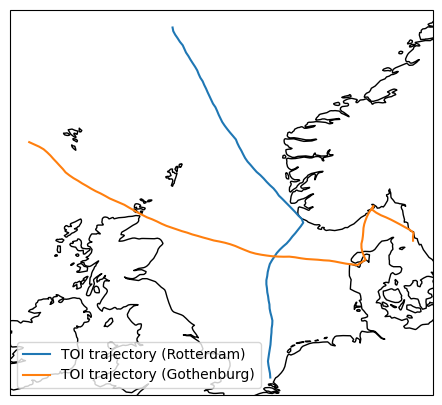

In [54]:
figglobal = plt.figure(figsize=(10,5))
axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
# axglobal.set_global()
axglobal.coastlines()

axglobal.plot([pos.lon_deg for pos in phenomena_rotterdam],[pos.lat_deg for pos in phenomena_rotterdam],transform=ccrs.Geodetic(), label="TOI trajectory (Rotterdam)")

axglobal.plot([pos.lon_deg for pos in phenomena_gothenburg],[pos.lat_deg for pos in phenomena_gothenburg],transform=ccrs.Geodetic(), label="TOI trajectory (Gothenburg)")


axglobal.legend()


## Initialize the world, the constellations, and the brokers

In [55]:
# phenomena = []

world_with_brokers = World(satellites = all_satellites, phenomena=phenomena_with_stationary_toi)

scheduler_planet = ConstellationGroundScheduler(satellites=dove_satellites+skysat_satellites+pelican_satellites+tanager_satellites, ground_stations=ground_stations, world=world_with_brokers, name="Planet")
scheduler_umbra = ConstellationGroundScheduler(satellites=umbra_satellites, ground_stations=ground_stations, world=world_with_brokers, name="Umbra")
scheduler_capella = ConstellationGroundScheduler(satellites=capella_acadia_satellites, ground_stations=ground_stations, world=world_with_brokers, name="Capella")
scheduler_LOFT = ConstellationGroundScheduler(satellites=loft_satellites, ground_stations=ground_stations, world=world_with_brokers, name="LOFT")
scheduler_ubotica = ConstellationGroundScheduler(satellites=ubotica_satellites, ground_stations=ground_stations, world=world_with_brokers, name="UBOTICA")
scheduler_mission_control = ConstellationGroundScheduler(satellites=mission_control_satellites, ground_stations=ground_stations, world=world_with_brokers, name="Mission Control")
scheduler_aerospace = ConstellationGroundScheduler(satellites=aerospace_corp_satellites, ground_stations=ground_stations, world=world_with_brokers, name="AC")
scheduler_iceye = ConstellationGroundScheduler(satellites=iceye_satellites, ground_stations=ground_stations, world=world_with_brokers, name="ICEYE")


world_with_brokers.add_constellation(scheduler_planet)
world_with_brokers.add_constellation(scheduler_umbra)
world_with_brokers.add_constellation(scheduler_capella)
world_with_brokers.add_constellation(scheduler_LOFT)
world_with_brokers.add_constellation(scheduler_ubotica)
world_with_brokers.add_constellation(scheduler_mission_control)
world_with_brokers.add_constellation(scheduler_aerospace)
world_with_brokers.add_constellation(scheduler_iceye)

broker = Broker(constellations=[scheduler_planet, scheduler_umbra, scheduler_capella, scheduler_iceye, scheduler_LOFT, scheduler_ubotica, scheduler_mission_control, scheduler_aerospace], world=world_with_brokers, name="Broker 1")

other_broker = Broker(constellations=[scheduler_planet, scheduler_umbra, scheduler_capella, scheduler_iceye, scheduler_LOFT, scheduler_ubotica, scheduler_mission_control, scheduler_aerospace], world=world_with_brokers, name="Broker 2")


world_with_brokers.add_broker(broker)
# world_with_brokers.add_broker(other_broker)

world_with_brokers.time = min_time

### Create the observation requests (the geometry)

In [56]:


obs_request_initial_msa_R = ObservationRequest(
    Rotterdam.lon_deg,
    Rotterdam.lat_deg,
    min_time=min_time,
    max_time=min_time+dt.timedelta(hours=3),
    alt_km=Rotterdam.alt_km,
    request_name="Initial RGB request in Rotterdam",
    min_elevation_deg=45,
    instrument=InstrumentType.RGB
    )

obs_request_followup_no_msa_R = ObservationRequest(
    Rotterdam.lon_deg,
    Rotterdam.lat_deg,
    min_time=min_time,
    max_time=max_time,
    alt_km=Rotterdam.alt_km,
    request_name="Follow-up search request in Rotterdam",
    min_elevation_deg=45,
    instrument=InstrumentType.SAR
    )

obs_request_followup_yes_msa_R = ObservationRequest(
    Rotterdam.lon_deg,
    Rotterdam.lat_deg,
    min_time=min_time,
    max_time=max_time,
    alt_km=Rotterdam.alt_km,
    request_name="Follow-up imaging request in Rotterdam",
    min_elevation_deg=45,
    instrument=InstrumentType.RGB
    )



obs_request_initial_msa_G = ObservationRequest(
    Gothenburg.lon_deg,
    Gothenburg.lat_deg,
    min_time=min_time,
    max_time=min_time+dt.timedelta(hours=4),
    alt_km=Gothenburg.alt_km,
    request_name="Initial RGB request in Gothenburg",
    min_elevation_deg=45,
    instrument=InstrumentType.RGB
    )

obs_request_followup_no_msa_G = ObservationRequest(
    Gothenburg.lon_deg,
    Gothenburg.lat_deg,
    min_time=min_time,
    max_time=max_time,
    alt_km=Gothenburg.alt_km,
    request_name="Follow-up search request in Gothenburg",
    min_elevation_deg=45,
    instrument=InstrumentType.SAR
    )

obs_request_followup_yes_msa_G = ObservationRequest(
    Gothenburg.lon_deg,
    Gothenburg.lat_deg,
    min_time=min_time,
    max_time=max_time,
    alt_km=Gothenburg.alt_km,
    request_name="Follow-up imaging request in Gothenburg",
    min_elevation_deg=45,
    instrument=InstrumentType.RGB
    )

## Create the workflow!

We start with some static functions we will use to compute rewards

In [57]:
def rewarder_observation(opportunity: ObservationOpportunity, preferred_zenith_angle_deg=45):

    static_reward = 50
    
    look_angle_reward = abs(90.-opportunity.look_angle_dec_deg)/90.
    
    zenith_angle_reward = abs(preferred_zenith_angle_deg-opportunity.sun_zenith_angle_deg)/90
    
    # if the Sun is below the horizon
    # if abs(opportunity.sun_zenith_angle_deg)>90 and opportunity.instrument == InstrumentType.RGB:
    #     zenith_angle_reward = -100

    range_reward = 1/(opportunity.range_km/1000)

    return look_angle_reward+zenith_angle_reward+range_reward+static_reward

def rewarder_search(opportunity: ObservationOpportunity, preferred_zenith_angle_deg=45):

    static_reward = 0
    look_angle_reward = abs(90.-opportunity.look_angle_dec_deg)/90.
    zenith_angle_reward = 0
    range_reward = 1/(opportunity.range_km/1000)
    return look_angle_reward+zenith_angle_reward+range_reward+static_reward

def success_declarer_msa_R(data_product):
    return len(data_product)>0

def success_declarer_msa_G(data_product):
    return len(data_product)>0

We create the actual constrained requests and timelines

In [58]:
from fame_msa_utils import custom_ship_phenomenon_processor


MAX_SEARCHES_PER_INTERVAL = 10
dt_h = 3
lookahead_horizon_h = 24

ship_location_timeline_msa = Timeline(name="Ship loc. known?", initial_time=min_time, initial_value=1, initial_rate=-1./10800, min_value=-100, max_value=100)



constrained_initial_observation_msa = ConstrainedObservationRequest(
    name = "Initial observation",
    observation_request=obs_request_initial_msa_R,
    success_declarer=success_declarer_msa_R,
    is_mandatory=True,
    timeline_constraints=[],
    timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline_msa, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],
    rewarder=rewarder_observation,
)

workflow_msa_reqs = [constrained_initial_observation_msa]

# For every window
# Look at the previous window
# If there was a search OR an imaging task AND it was successful, schedule an imaging task.
# If there was a search OR an imaging task AND it was UNsuccessful, schedule a search task
# If there was neither, schedule a search task
#   We do not have the syntax for this.
# A simpler state-based reasoning:
# If we know where the boat is, schedule an imaging task
# If we do not, schedule a search task
# Are we reinventing MEXEC? Kinda...

# If the prior is successful, do a SAR request
for h_ix in list(range(dt_h,lookahead_horizon_h,dt_h)):

    num_requests_in_previous_batches = len(workflow_msa_reqs)

    obs_task_constraints = [
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_initial_observation_msa, {'offset': dt.timedelta(seconds=3600*h_ix)}),
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_initial_observation_msa, {'offset': dt.timedelta(seconds=3600*(h_ix+dt_h))}),
            # Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, workflow_msa_reqs[-1]), # Start if the previous observation was done or is infeasible
            # Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, workflow_longer_reqs[-1]),
        ]
    # if len(workflow_msa_reqs)>1:
    #     obs_task_constraints.append(
    #         Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, workflow_msa_reqs[-2]), # Start if the previous search was done or is infeasible
    #     )
    for existing_request in workflow_msa_reqs[:num_requests_in_previous_batches]:
        obs_task_constraints.append(
            Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, existing_request), # Start if the previous search was done or is infeasible
        )



    obs_request_followup_yes_msa_Rotterdam = ObservationRequest(
        Rotterdam.lon_deg,
        Rotterdam.lat_deg,
        min_time=min_time+dt.timedelta(seconds=3600*h_ix),
        max_time=min_time+dt.timedelta(seconds=3600*(h_ix+dt_h)),
        alt_km=Rotterdam.alt_km,
        request_name="Follow-up imaging request {} in Rotterdam".format(int(h_ix/dt_h)),
        min_elevation_deg=45,
        instrument=InstrumentType.RGB
        )

    constrained_followup_observation_later = ConstrainedObservationRequest(
        name="Follow-up obs. {}".format(int(h_ix/dt_h)),
        observation_request=obs_request_followup_yes_msa_Rotterdam,
        task_constraints = obs_task_constraints,
        schedule_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
        dispatch_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: False, ConstraintClass.SUCCESS: False, ConstraintClass.GEOMETRY: False},
        success_declarer=success_declarer_msa_R,
        timeline_constraints=[TaskTimelineConstraint(timeline=ship_location_timeline_msa, time=TaskImpactTime.PRE, type=TimelineConstraintType.GREATER_OR_EQUAL, value=0),],
        timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline_msa, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],
        rewarder=rewarder_observation,
        max_num_instances=1,
        plotting_group="Follow-up obs. {}".format(int(h_ix/dt_h)),
    )

    for search_ix in range(MAX_SEARCHES_PER_INTERVAL):

        obs_request_followup_no_msa_Rotterdam = ObservationRequest(
            Rotterdam.lon_deg,
            Rotterdam.lat_deg,
            min_time=min_time+dt.timedelta(seconds=3600*h_ix),
            max_time=min_time+dt.timedelta(seconds=3600*(h_ix+dt_h)),
            alt_km=Rotterdam.alt_km,
            request_name="Follow-up search request {}.{} in Rotterdam".format(int(h_ix/dt_h), search_ix),
            min_elevation_deg=45,
            instrument=InstrumentType.SAR
            )
        obs_srch_constraints = [
                Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, constrained_initial_observation_msa, {'offset': dt.timedelta(seconds=3600*h_ix)}),
                Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, constrained_initial_observation_msa, {'offset': dt.timedelta(seconds=3600*(h_ix+dt_h))}),
                # Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, workflow_msa_reqs[-1]), # Start if the previous observation was done or is infeasible
                # Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, workflow_longer_reqs[-1]),
            ]
        # if len(workflow_msa_reqs)>1:
        #     obs_srch_constraints.append(
        #         Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, workflow_msa_reqs[-2]), # Start if the previous search was done or is infeasible
        #     )
        for existing_request in workflow_msa_reqs[:num_requests_in_previous_batches]:
            obs_srch_constraints.append(
                Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, existing_request), # Start if the previous search was done or is infeasible
            )

        # If the prior fails, do a search
        constrained_followup_search_later = ConstrainedObservationRequest(
            name="Follow-up search {}.{}".format(int(h_ix/dt_h), search_ix),
            observation_request=obs_request_followup_no_msa_Rotterdam,
            task_constraints = obs_srch_constraints,
            schedule_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
            dispatch_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: False, ConstraintClass.SUCCESS: False, ConstraintClass.GEOMETRY: False},
            success_declarer=success_declarer_msa_R,
            timeline_constraints=[TaskTimelineConstraint(timeline=ship_location_timeline_msa, time=TaskImpactTime.PRE, type=TimelineConstraintType.LESSER_OR_EQUAL, value=0),],
            timeline_impacts=[TaskTimelineImpact(timeline=ship_location_timeline_msa, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=0.1)],
            rewarder=rewarder_search,
            max_num_instances=1,
            plotting_group="Follow-up search {}".format(int(h_ix/dt_h)),
        )

        workflow_msa_reqs.append(constrained_followup_search_later)

    workflow_msa_reqs.append(constrained_followup_observation_later)


We also create the functions that update the timelines and the tasks when new information arrives. These are invoked just before replanning


In [ ]:

def timeline_updater_msa(current_time: dt.datetime, requests: list[ConstrainedObservationRequest], timelines: list[Timeline], max_time_without_observations: dt.timedelta=dt.timedelta(seconds=10800), verbose=True):
    # What time is it?
    # Did we have a successful search or imaging in the recent past?
    # If we did, set timeline start to 1
    # If we did not, set timeline start to 0
    # Keep the current rate
    ship_position_is_known = False
    for current_request in requests:
        if (current_request.completed is True):
            if (current_request.successful_execution is True):
                if (current_time-current_request.observation_opportunity.time)<max_time_without_observations:
                    ship_position_is_known = True
                    break
    
    ship_position_timeline = timelines[0]
    if ship_position_is_known:
        current_measured_value = 1
    else:
        current_measured_value = 0

    _current_estimated_value, _current_estimated_rate = ship_position_timeline._get_value_and_rate_at(current_time, print_debug=False)

    ship_position_timeline.reset_timeline(current_time, current_measured_value, _current_estimated_rate)
    if verbose:
        print(f"    [Dispatcher] Resetting timeline {ship_position_timeline} to {current_measured_value} (est rate {_current_estimated_rate}) at time {current_time}")
    return timelines

def request_updater_msa(
        current_time: dt.datetime,
        requests: list[ConstrainedObservationRequest],
        timelines: list[Timeline]=[],
        verbose=True,
        initial_toi_pose:
        Pose=Rotterdam,
        search_name_str: str="",
        samples_propagation=200,
        plot_filter_distribution: bool=False,
        plot_axis: plt.axis = None,
        save_filter_distribution: bool=False,
        save_name: str=None,
        ):
    # ShipTracker ingests measurements via update_location and propagates said locations via propagate_locations.
    # Workflow:
    # Look for the latest observation in completed requests.
    
    initial_ship_location = Pose(time=min_time, lon_deg=initial_toi_pose.lon_deg, lat_deg=initial_toi_pose.lat_deg, alt_km=initial_toi_pose.alt_km, heading_deg=initial_toi_pose.heading_deg, speed_kph=initial_toi_pose.speed_kph)

    completed_requests = [r for r in requests if r.completed == True]
    # Walk from most recent backward to find the most recent time we saw the ship
    completed_requests.sort(key=lambda x: x.observation_opportunity.time, reverse=True)
    found_latest_request = False
    for completed_request in completed_requests:
        if len(completed_request.data_product):
            for ship_location_phenomenon in completed_request.data_product:
                # If the ship is the right one
                if ((len(search_name_str)==0) or (search_name_str in ship_location_phenomenon.name)):
                    if verbose:
                        print(f"Reinitializing the filter at {completed_request.observation_opportunity.time} (phenomenon {ship_location_phenomenon} matches string {search_name_str})")
                    found_latest_request = True
                    initial_ship_location = custom_ship_phenomenon_processor(
                        observation=completed_request.observation_opportunity,
                        spacecraft=completed_request.observation_opportunity.satellite,
                        phenomenon=ship_location_phenomenon
                        )
                    break
        if found_latest_request:
            break

    ship_tracker = ShipTracker(initial_pose=initial_ship_location, pose_propagator=ship_propagator)
    # Order unfilled requests by min_time.
    unfilled_requests = [r for r in requests if r.completed == False and r.dispatched == False and r.feasible == True and r.observation_request.max_time>current_time]
    # print(f"Unfilled requests ({len(unfilled_requests)}): {unfilled_requests}")
    unfilled_requests_dict_by_time = {}
    for ur in unfilled_requests:
        urtime = ur.observation_request.min_time+(ur.observation_request.max_time-ur.observation_request.min_time)/2
        if urtime not in unfilled_requests_dict_by_time.keys():
            unfilled_requests_dict_by_time[urtime] = []
        unfilled_requests_dict_by_time[urtime].append(ur)

    # For each batch of requests, plan_next_search_locations with max_search_locations=the number of requests you have and update the locations.

    unfilled_request_times = list(unfilled_requests_dict_by_time.keys())
    unfilled_request_times.sort()
    # print(f"Unfilled request times ({len(unfilled_request_times)}): {unfilled_request_times}")

    if plot_filter_distribution:
        if plot_axis is None:
            figglobal = plt.figure(figsize=(10,5))
            plot_axis = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
            plot_axis.coastlines()

            fig_distribution, plot_distribution = plt.subplots(figsize=(10,5))
            plot_distribution.set_title("Cumulative distribution across hexagons")

    for urtime in unfilled_request_times:
        num_requests_at_this_time = len(unfilled_requests_dict_by_time[urtime])
        # Get as many samples as we have requests at this time
        # print("Starting propagation...")
        ship_tracker.propagate_locations(urtime, samples=samples_propagation, max_dt=dt.timedelta(hours=3))
        # print("done, starting pruning...")
        ship_tracker.prune_locations(samples=samples_propagation) # Samples in propagate_location doesn't exactly do what we want...
        # print("done, creating GPD frame...")
        # Give the locations to the requests
        # assert len(ship_tracker.estimated_locations)==num_requests_at_this_time, "ERROR: too many or too few samples propagated"
        
        # TESSELLATE WHAT YOU FOUND AND ADD REQUESTS ACCORDINGLY

        # Plot
        # if plot_filter_distribution:
        #     plot_axis.plot([pos.lon_deg for pos in ship_tracker.estimated_locations],[pos.lat_deg for pos in ship_tracker.estimated_locations],'.', transform=ccrs.Geodetic(), label=urtime)
        
        points_gpd = gpd.GeoDataFrame(
            {'lon': [pos.lon_deg for pos in ship_tracker.estimated_locations], 'lat': [pos.lat_deg for pos in ship_tracker.estimated_locations]},
            geometry=gpd.points_from_xy([pos.lon_deg for pos in ship_tracker.estimated_locations], [pos.lat_deg for pos in ship_tracker.estimated_locations]),
            crs="EPSG:4326"
        )
        tess_bounds = points_gpd.total_bounds
        tess_bbox = shapely.box(tess_bounds[0], tess_bounds[1], tess_bounds[2], tess_bounds[3])
        aoi_gdf = gpd.GeoDataFrame(geometry=[tess_bbox], crs=points_gpd.crs)

        points_tessellation = tesspy.Tessellation(aoi_gdf)
        # Res 5: 9.85 km side. Res 6: 3.72 km side
        points_hex_tessellation = points_tessellation.hexagons(resolution=5)
        # Counting points in each hex
        joined_hexagons_and_points = gpd.sjoin(points_hex_tessellation, points_gpd, how="left", predicate="intersects")
        points_hex_tessellation['point_count'] = joined_hexagons_and_points.groupby(joined_hexagons_and_points.index)['index_right'].count()

        points_hex_tessellation.sort_values(by='point_count', ascending=False, inplace=True)
        total_points = len(ship_tracker.estimated_locations)
        cumulative_points = 0
        point_distribution = []
        for index, row in points_hex_tessellation.iterrows():
            points = row['point_count']
            cumulative_points+=points
            point_distribution.append(cumulative_points/total_points)
        
        if plot_filter_distribution:
            # print("Done, plotting")
            points_gpd.plot(ax=plot_axis, transform=ccrs.Geodetic(), markersize=3, label=urtime,alpha=.1)
            points_hex_tessellation.plot(
                ax=plot_axis,
                transform=ccrs.PlateCarree(), 
                column='point_count',
                cmap='Blues',
                alpha=.9,
                # vmax=points_hex_tessellation['point_count'].max() + 1
                )
            
            plot_distribution.plot(list(range(len(point_distribution))), point_distribution, label=urtime)
        
        # if False:
        for unfulfilled_request_ix, unfulfilled_request in enumerate(unfilled_requests_dict_by_time[urtime]):
            if unfulfilled_request_ix>len(points_hex_tessellation):
                # We have run out of hexagons. Which is good! We should remove this request and the following ones
                break
            hex_centroid = points_hex_tessellation.iloc[unfulfilled_request_ix].geometry.centroid
            _updated_request = ObservationRequest(
                lat_deg=hex_centroid.y,
                lon_deg=hex_centroid.x,
                min_time=unfulfilled_request.observation_request.min_time,
                max_time = unfulfilled_request.observation_request.max_time,
                alt_km=unfulfilled_request.observation_request.alt_km,
                instrument=unfulfilled_request.observation_request.instrument,
                request_name=unfulfilled_request.observation_request.name,
                min_elevation_deg=unfulfilled_request.observation_request.min_elevation_deg,
            )
            unfulfilled_request.observation_request = _updated_request
        # fi

    plt.legend()
    if save_filter_distribution:
        if save_name is None:
            save_name = f"media/Tracker_{current_time}.png"
        plot_axis.figure.savefig(save_name, bbox_inches='tight')

        plot_distribution.set_xlim(0,25)
        plot_distribution.figure.savefig(f"media/Tracker_distribution_{current_time}.png", bbox_inches='tight')
    return requests



### Create the workflow proper

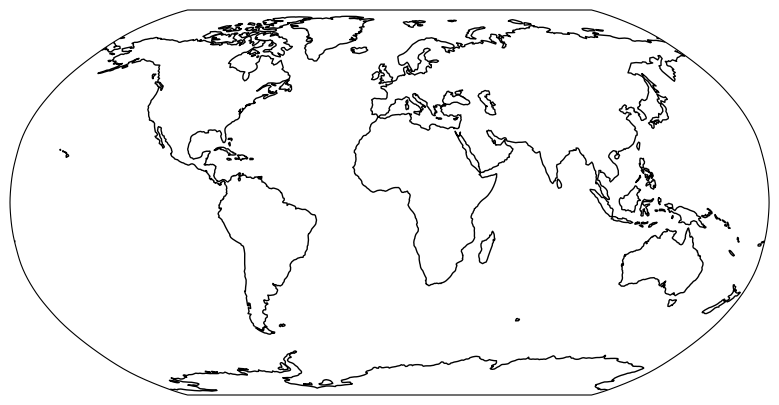

In [60]:
fig_filter_broker1 = plt.figure(figsize=(10,5))
plot_axis_broker1 = fig_filter_broker1.add_subplot(1,1,1, projection=ccrs.Robinson())
plot_axis_broker1.coastlines()

workflow_msa = Workflow(
    constrained_observation_requests=workflow_msa_reqs,
    timelines = [ship_location_timeline_msa,],
    timeline_updater=timeline_updater_msa,
    request_updater=lambda current_time, requests, timelines: request_updater_msa(
        current_time=current_time,
        requests=requests,
        timelines=timelines,
        verbose=True,
        initial_toi_pose=initial_toi_pose_rotterdam,
        search_name_str="Rotterdam",
        plot_filter_distribution=True,
        # plot_axis=plot_axis_broker1,
        save_filter_distribution=True,
        ),
)

In [61]:
broker.add_workflow(workflow_msa)

#### ... and we do the same for the second broker

In [62]:
other_ship_location_timeline_msa = Timeline(name="Ship loc. known?", initial_time=min_time, initial_value=1, initial_rate=-1./10800, min_value=-100, max_value=100)



other_constrained_initial_observation_msa = ConstrainedObservationRequest(
    name = "Initial observation",
    observation_request=obs_request_initial_msa_G,
    success_declarer=success_declarer_msa_G,
    is_mandatory=True,
    timeline_constraints=[],
    timeline_impacts=[TaskTimelineImpact(timeline=other_ship_location_timeline_msa, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],
    rewarder=rewarder_observation,
)

other_workflow_msa_reqs = [other_constrained_initial_observation_msa]

# For every window
# Look at the previous window
# If there was a search OR an imaging task AND it was successful, schedule an imaging task.
# If there was a search OR an imaging task AND it was UNsuccessful, schedule a search task
# If there was neither, schedule a search task
#   We do not have the syntax for this.
# A simpler state-based reasoning:
# If we know where the boat is, schedule an imaging task
# If we do not, schedule a search task
# Are we reinventing MEXEC? Kinda...

# If the prior is successful, do a SAR request
for h_ix in list(range(dt_h,lookahead_horizon_h,dt_h)):

    num_requests_in_previous_batches = len(other_workflow_msa_reqs)

    obs_task_constraints = [
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, other_constrained_initial_observation_msa, {'offset': dt.timedelta(seconds=3600*h_ix)}),
            Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, other_constrained_initial_observation_msa, {'offset': dt.timedelta(seconds=3600*(h_ix+dt_h))}),
            # Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, workflow_msa_reqs[-1]), # Start if the previous observation was done or is infeasible
            # Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, workflow_longer_reqs[-1]),
        ]
    # if len(workflow_msa_reqs)>1:
    #     obs_task_constraints.append(
    #         Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, workflow_msa_reqs[-2]), # Start if the previous search was done or is infeasible
    #     )
    for existing_request in other_workflow_msa_reqs[:num_requests_in_previous_batches]:
        obs_task_constraints.append(
            Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, existing_request), # Start if the previous search was done or is infeasible
        )

    other_constrained_followup_observation_later = ConstrainedObservationRequest(
        name="Follow-up obs. {}".format(int(h_ix/dt_h)),
        observation_request=obs_request_followup_yes_msa_G,
        task_constraints = obs_task_constraints,
        schedule_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
        dispatch_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: False, ConstraintClass.SUCCESS: False, ConstraintClass.GEOMETRY: False},
        success_declarer=success_declarer_msa_G,
        timeline_constraints=[TaskTimelineConstraint(timeline=other_ship_location_timeline_msa, time=TaskImpactTime.PRE, type=TimelineConstraintType.GREATER_OR_EQUAL, value=0),],
        timeline_impacts=[TaskTimelineImpact(timeline=other_ship_location_timeline_msa, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],
        rewarder=rewarder_observation,
        max_num_instances=1
    )

    for search_ix in range(MAX_SEARCHES_PER_INTERVAL):
        obs_srch_constraints = [
                Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_AFTER_OFFSET, other_constrained_initial_observation_msa, {'offset': dt.timedelta(seconds=3600*h_ix)}),
                Constraint(ConstraintClass.TEMPORAL, TemporalConstraintType.START_BEFORE_OFFSET, other_constrained_initial_observation_msa, {'offset': dt.timedelta(seconds=3600*(h_ix+dt_h))}),
                # Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, workflow_msa_reqs[-1]), # Start if the previous observation was done or is infeasible
                # Constraint(ConstraintClass.GEOMETRY, GeometryConstraintType.LLA, workflow_longer_reqs[-1]),
            ]
        # if len(workflow_msa_reqs)>1:
        #     obs_srch_constraints.append(
        #         Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, workflow_msa_reqs[-2]), # Start if the previous search was done or is infeasible
        #     )
        for existing_request in other_workflow_msa_reqs[:num_requests_in_previous_batches]:
            obs_srch_constraints.append(
                Constraint(ConstraintClass.SUCCESS, SuccessConstraintType.WAIT_FOR_COMPLETION_IF_FEASIBLE, existing_request), # Start if the previous search was done or is infeasible
            )

        # If the prior fails, do a search
        other_constrained_followup_search_later = ConstrainedObservationRequest(
            name="Follow-up search {}.{}".format(int(h_ix/dt_h), search_ix),
            observation_request=obs_request_followup_no_msa_G,
            task_constraints = obs_srch_constraints,
            schedule_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: True, ConstraintClass.SUCCESS: True, ConstraintClass.GEOMETRY: True},
            dispatch_policy_if_constraint_unsatisfied={ConstraintClass.TEMPORAL: False, ConstraintClass.SUCCESS: False, ConstraintClass.GEOMETRY: False},
            success_declarer=success_declarer_msa_G,
            timeline_constraints=[TaskTimelineConstraint(timeline=other_ship_location_timeline_msa, time=TaskImpactTime.PRE, type=TimelineConstraintType.LESSER_OR_EQUAL, value=0),],
            timeline_impacts=[TaskTimelineImpact(timeline=other_ship_location_timeline_msa, time=TaskImpactTime.POST, type=ImpactType.ADDITION, value=1.)],
            rewarder=rewarder_search,
            max_num_instances=1,
        )

        other_workflow_msa_reqs.append(other_constrained_followup_search_later)

    other_workflow_msa_reqs.append(other_constrained_followup_observation_later)

def other_timeline_updater_msa(current_time: dt.datetime, requests: list[ConstrainedObservationRequest], timelines: list[Timeline], max_time_without_observations: dt.timedelta=dt.timedelta(seconds=10800), verbose=True):
    # What time is it?
    # Did we have a successful search or imaging in the recent past?
    # If we did, set timeline start to 1
    # If we did not, set timeline start to 0
    # Keep the current rate
    ship_position_is_known = False
    for current_request in requests:
        if (current_request.completed is True):
            if (current_request.successful_execution is True):
                if (current_time-current_request.observation_opportunity.time)<max_time_without_observations:
                    ship_position_is_known = True
                    break
    
    ship_position_timeline = timelines[0]
    if ship_position_is_known:
        current_measured_value = 1
    else:
        current_measured_value = 0

    _current_estimated_value, _current_estimated_rate = ship_position_timeline._get_value_and_rate_at(current_time, print_debug=False)

    ship_position_timeline.reset_timeline(current_time, current_measured_value, _current_estimated_rate)
    if verbose:
        print(f"    [Dispatcher] Resetting timeline {ship_position_timeline} to {current_measured_value} (est rate {_current_estimated_rate}) at time {current_time}")
    return timelines

def other_request_updater_msa(current_time: dt.datetime, requests: list[ConstrainedObservationRequest], timelines: list[Timeline], verbose=True):
  # ShipTracker ingests measurements via update_location and propagates said locations via propagate_locations.
  # Workflow:
  # Look for the latest observation in completed requests.
  # Initialize the ShipTracker with that location. Ignore previous detections.
  # Order unfilled requests by min_time.
  # For each batch of requests, plan_next_search_locations with max_search_locations=the number of requests you have and update the locations.
  return requests

other_workflow_msa = Workflow(
    constrained_observation_requests=other_workflow_msa_reqs,
    timelines = [other_ship_location_timeline_msa,],
    timeline_updater=other_timeline_updater_msa,
    # request_updater=other_request_updater_msa,
)


other_broker.add_workflow(other_workflow_msa)



#### Set up plotting

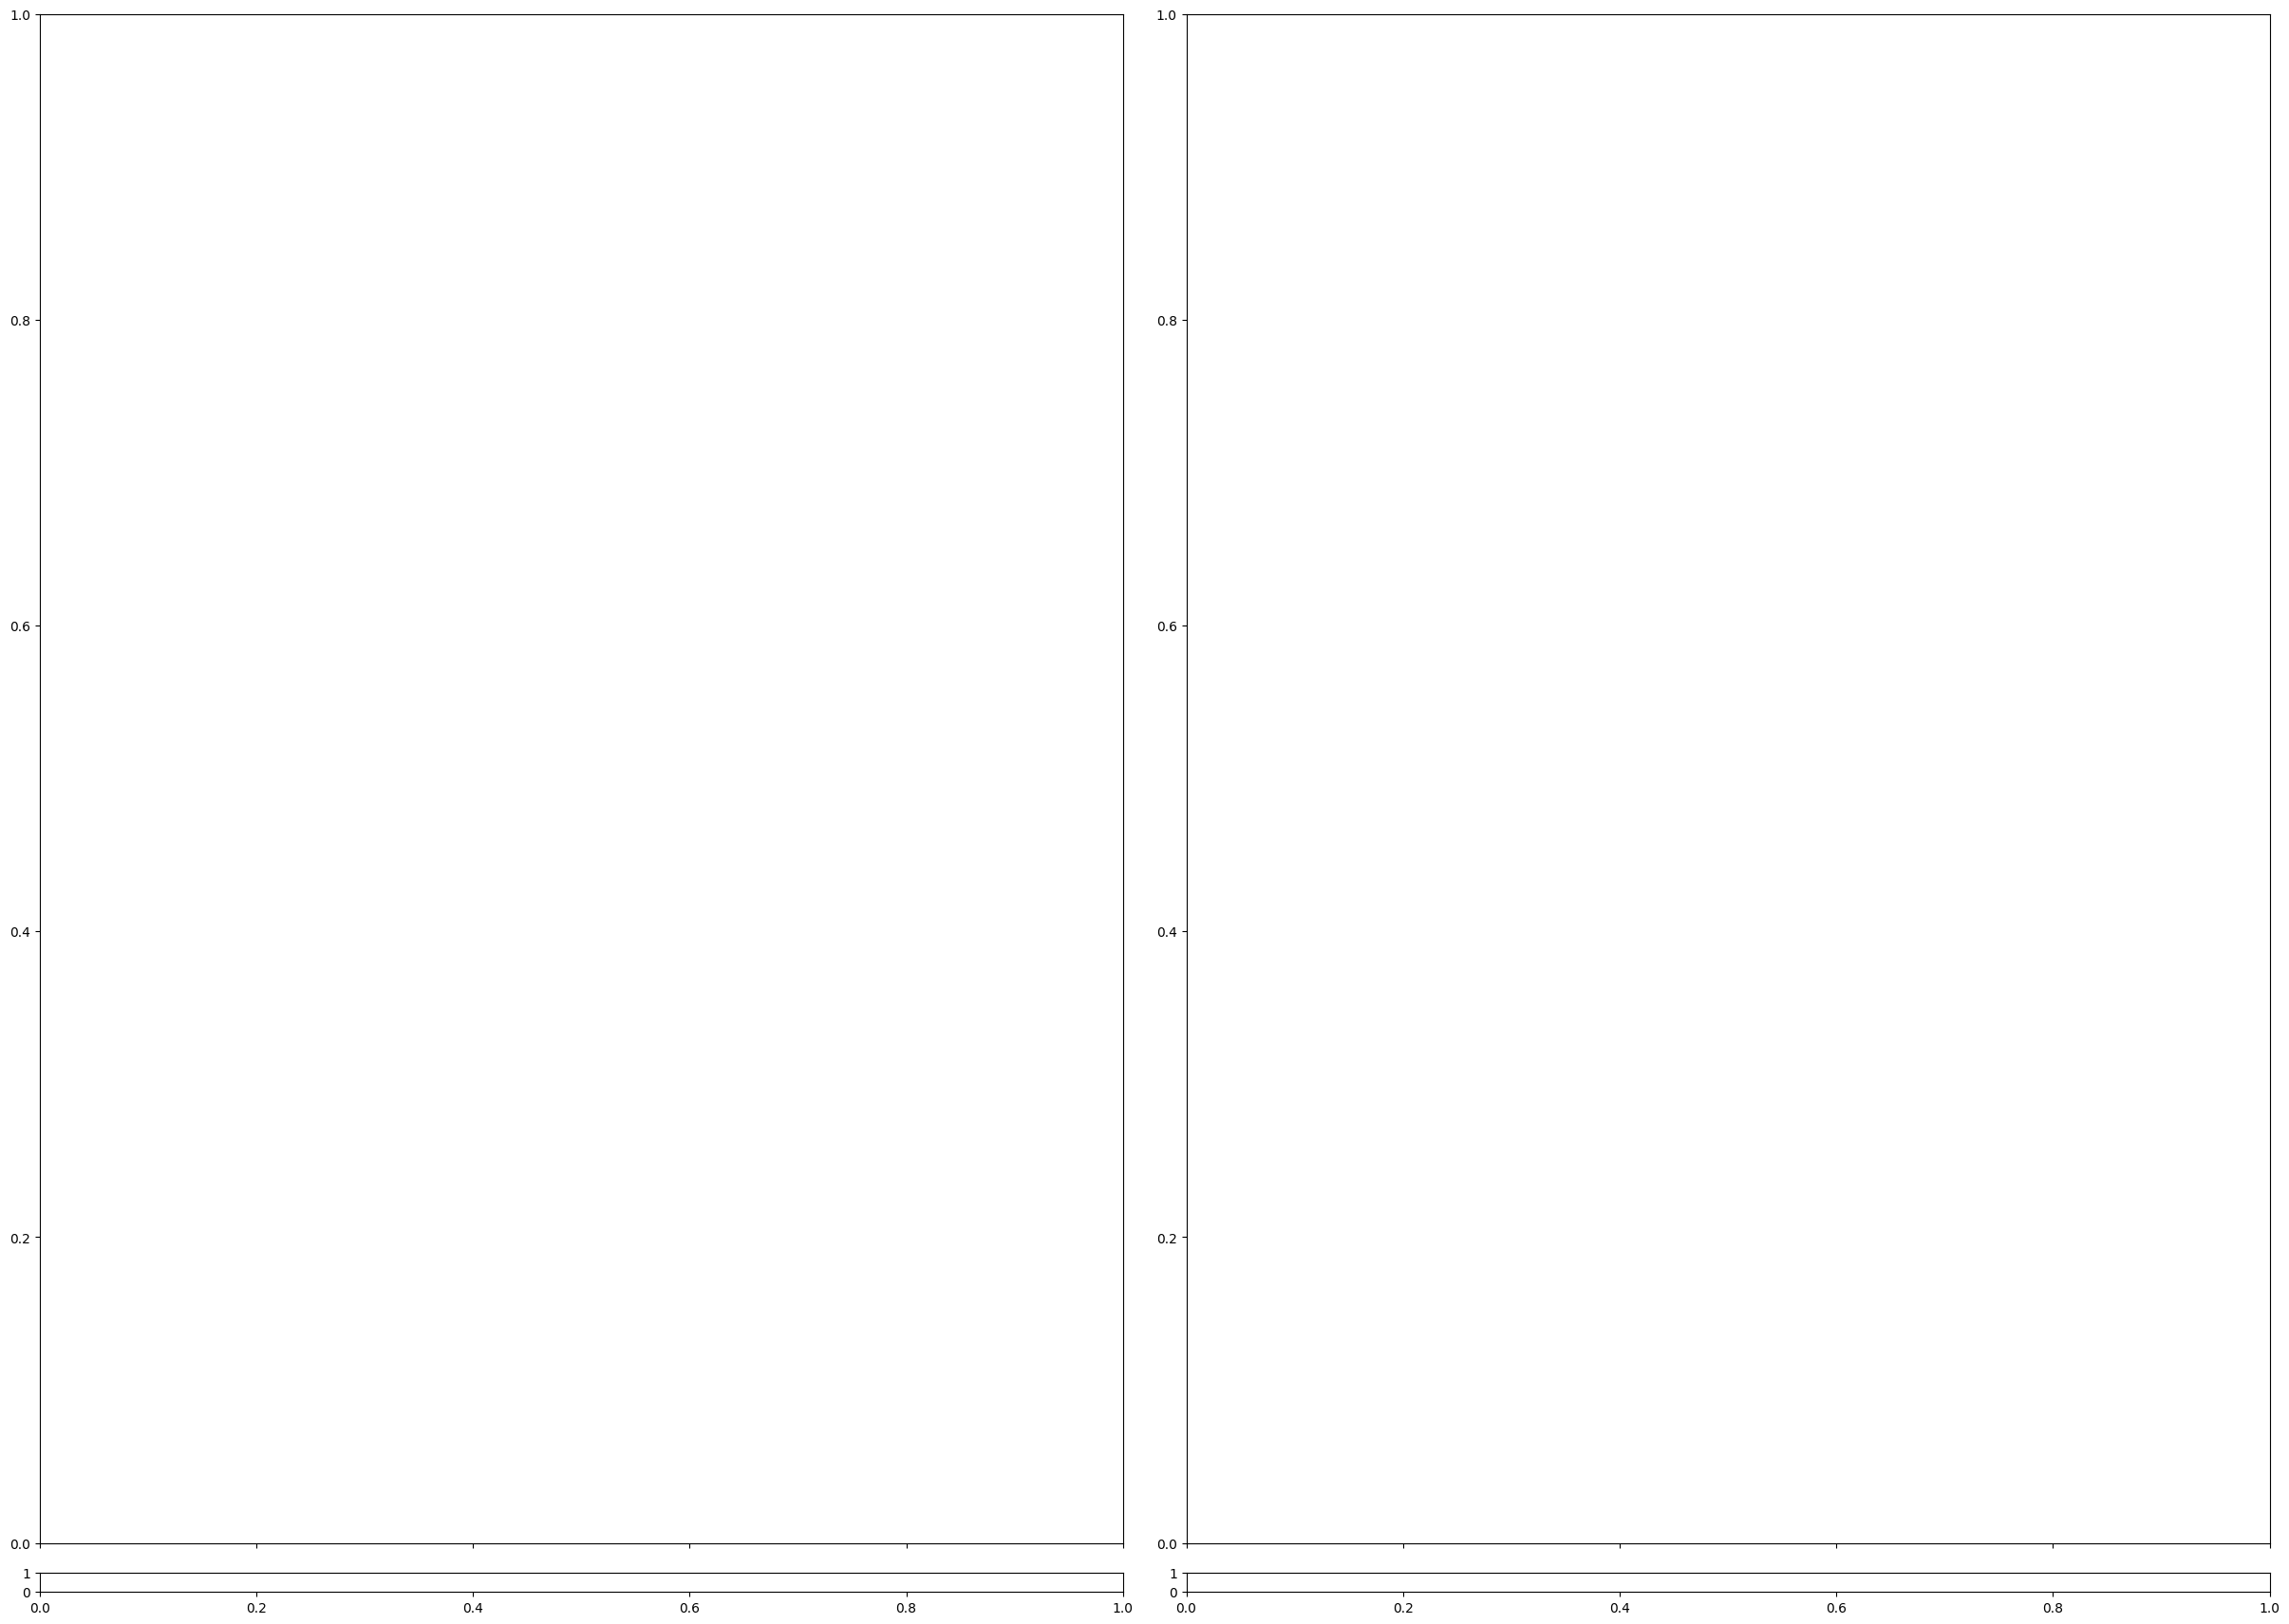

In [63]:
# Plot the timelines

num_requests = max([len(b.workflow.constrained_observation_requests) for b in world_with_brokers.brokers])
num_timelines = max([len(b.workflow.timelines) for b in world_with_brokers.brokers])

height_ratios = [num_requests]
height_ratios.extend([1,]*num_timelines)

fig, baxes = plt.subplots(
    num_timelines+1,
    len(world_with_brokers.brokers),
    sharex=True,
    height_ratios=height_ratios,
    figsize=(12*len(world_with_brokers.brokers), int(math.ceil(.2*num_requests+num_timelines))),
    layout="constrained"
    )

broker_axes = {}
if len(world_with_brokers.brokers)>1:
    for broker_ix, _broker in enumerate(world_with_brokers.brokers):
        broker_axes[_broker] = baxes[:, broker_ix]
else:
    broker_axes[world_with_brokers.brokers[0]] = baxes

In [64]:
world_with_brokers.brokers

[<fame_broker.Broker at 0x1370da7b0>, <fame_broker.Broker at 0x3440391d0>]

## Start the workflows!

In [65]:
broker.schedule_workflow(
    current_time=world_with_brokers.time,
    use_ilp=False,
    plot_schedule=True,
    plot_axes=broker_axes[broker],
    update_timelines=False, # Only the first time
    update_requests=False, # Only the first time
    plot_night_in_schedule=True,
    plot_location_for_night_in_schedule=Rotterdam,
    save_schedule_plot=True,
    max_solver_time_s=300
    )

   [Scheduler] Scheduled request Initial observation on SKYSAT-C8 at Observation  at 2026-01-21 01:20:51.804103 by SKYSAT-C8 with InstrumentType.RGB. Look angle 70.6617002322104 | 70.88258362897082 az/dec deg, zenith angle 143.91817658143063 deg, range 498.369888870681 km, duration 0:01:00
   [Scheduler] Scheduled request Follow-up search 1.0 on ICEYE-X11 at Observation  at 2026-01-21 04:44:55.972495 by ICEYE-X11 with InstrumentType.SAR. Look angle 256.493040636052 | 82.47587980927165 az/dec deg, zenith angle 116.41999691641404 deg, range 384.38743512399304 km, duration 0:01:00
   [Scheduler] Scheduled request Follow-up search 1.1 on ICEYE-X6 at Observation  at 2026-01-21 04:30:19.303064 by ICEYE-X6 with InstrumentType.SAR. Look angle 100.17727774348947 | 48.89910492306834 az/dec deg, zenith angle 118.66772147154774 deg, range 726.7721680567738 km, duration 0:01:00
   [Scheduler] Scheduled request Follow-up search 1.2 on CAPELLA-11 (ACADIA-1) at Observation  at 2026-01-21 05:15:07.5881

In [66]:
# other_broker.schedule_workflow(
#     current_time=world_with_brokers.time,
#     use_ilp=False,
#     plot_schedule=True,
#     plot_axes=broker_axes[other_broker],
#     update_timelines=False, # Only the first time
#     plot_night_in_schedule=True,
#     plot_location_for_night_in_schedule=Rotterdam,
#     save_schedule_plot=True,
#     ) #, max_solver_time_s=10)

Executing Event Obs, sat SKYSAT-C8 at 2026-01-21 01:20:50.691974
Executing Event ISL Downlink from sat SKYSAT-C8 at 2026-01-21 01:20:50.691974
Spacecraft SKYSAT-C8 has 1 data products to download
  Downlinked Observation  at 2026-01-21 01:20:50.691974 by SKYSAT-C8 with InstrumentType.RGB. Look angle 73.67140590040195 | 70.91069913214582 az/dec deg, zenith angle 143.9198268649537 deg, range 498.2774171919814 km, duration 0:01:00
 [Broker 1: ] data ready for request Request Initial RGB request in Rotterdam, pass Pass start: 2026-01-21 01:19:55.229277, highest: 2026-01-21 01:20:51.804103, fall: 2026-01-21 01:21:46.154671, from Planet
    [Dispatcher] Resetting timeline Timeline Ship loc. known? with 2 impacts to 1 (est rate -9.259259259259259e-05) at time 2026-01-21 01:20:50.691974
Found phenomenon Rotterdam-ish stationary
Reinitializing the filter here (matches string Rotterdam)
   [Scheduler] Scheduled request Follow-up search 1.0 on ICEYE-X11 at Observation  at 2026-01-21 04:44:55.3174

/var/folders/lh/6q0sr4nd33xbw9yv4jzsr6bm0000gq/T/ipykernel_46849/2083816596.py:88: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  figglobal = plt.figure(figsize=(10,5))


   [Scheduler] Scheduled request Follow-up search 3.0 on ICEYE-X33 at Observation  at 2026-01-21 11:11:23.794343 by ICEYE-X33 with InstrumentType.SAR. Look angle 248.32900088380566 | 82.45681868527478 az/dec deg, zenith angle 72.45649472039096 deg, range 580.1278624134853 km, duration 0:01:00
   [Scheduler] Scheduled request Follow-up search 3.1 on ICEYE-X42 at Observation  at 2026-01-21 11:25:15.410453 by ICEYE-X42 with InstrumentType.SAR. Look angle 281.53442918888135 | 66.35001833766285 az/dec deg, zenith angle 72.10757041944726 deg, range 649.2381205029602 km, duration 0:01:00
   [Scheduler] Could not schedule Follow-up search 3.3 (all conflicts)
   [Scheduler] Scheduled request Follow-up search 4.0 on ICEYE-X7 at Observation  at 2026-01-21 13:29:48.810079 by ICEYE-X7 with InstrumentType.SAR. Look angle 71.29300233940326 | 53.80235402473699 az/dec deg, zenith angle 74.62404052828187 deg, range 594.1384538293222 km, duration 0:01:00
   [Scheduler] Scheduled request Follow-up search 

/var/folders/lh/6q0sr4nd33xbw9yv4jzsr6bm0000gq/T/ipykernel_46849/2083816596.py:170: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


   [Scheduler] Scheduled request Follow-up search 7.0 on ICEYE-X51 at Observation  at 2026-01-21 22:39:14.805914 by ICEYE-X51 with InstrumentType.SAR. Look angle 110.78354598362317 | 70.75505364283521 az/dec deg, zenith angle 144.43916860415396 deg, range 602.7186536115274 km, duration 0:01:00
   [Scheduler] Scheduled request Follow-up search 7.1 on ICEYE-X46 at Observation  at 2026-01-21 22:58:59.699188 by ICEYE-X46 with InstrumentType.SAR. Look angle 281.7207348491334 | 66.68471354617833 az/dec deg, zenith angle 145.7910865866975 deg, range 638.0318077048915 km, duration 0:01:00
   [Scheduler] Scheduled request Follow-up search 7.2 on ICEYE-X50 at Observation  at 2026-01-21 22:29:48.100879 by ICEYE-X50 with InstrumentType.SAR. Look angle 97.76148236698131 | 62.73164118463095 az/dec deg, zenith angle 143.47640768845858 deg, range 658.8423504501505 km, duration 0:01:00
   [Scheduler] Scheduled request Follow-up search 7.5 on ICEYE-X48 at Observation  at 2026-01-21 22:42:34.014497 by IC

/var/folders/lh/6q0sr4nd33xbw9yv4jzsr6bm0000gq/T/ipykernel_46849/2083816596.py:170: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


   [Scheduler] Could not schedule Follow-up search 7.0 (all conflicts)
   [Scheduler] Could not schedule Follow-up search 7.1 (all conflicts)
   [Scheduler] Could not schedule Follow-up search 7.2 (all conflicts)
   [Scheduler] Could not schedule Follow-up search 7.5 (all conflicts)
   [Scheduler] Could not schedule Follow-up search 7.6 (all conflicts)
   [Scheduler] Could not schedule Follow-up search 7.7 (all conflicts)
   [Scheduler] Could not schedule Follow-up search 7.8 (all conflicts)
   [Scheduler] Could not schedule Follow-up search 7.9 (all conflicts)
 [Broker 1] There are 0 dispatchable tasks
Executing Event Obs, sat ICEYE-X52 at 2026-01-21 23:57:38.514410
Executing Event ISL Downlink from sat ICEYE-X52 at 2026-01-21 23:57:38.514410
Spacecraft ICEYE-X52 has 1 data products to download
  Downlinked Observation  at 2026-01-21 23:57:38.514410 by ICEYE-X52 with InstrumentType.SAR. Look angle 77.67587782540761 | 67.64862457671481 az/dec deg, zenith angle 147.76183984063883 deg, r

/var/folders/lh/6q0sr4nd33xbw9yv4jzsr6bm0000gq/T/ipykernel_46849/2083816596.py:170: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


   [Scheduler] Could not schedule Follow-up search 7.0 (no passes)
   [Scheduler] Could not schedule Follow-up search 7.1 (no passes)
   [Scheduler] Could not schedule Follow-up search 7.2 (no passes)
   [Scheduler] Could not schedule Follow-up search 7.5 (no passes)
   [Scheduler] Could not schedule Follow-up search 7.6 (no passes)
   [Scheduler] Could not schedule Follow-up search 7.7 (no passes)
   [Scheduler] Could not schedule Follow-up search 7.8 (no passes)
   [Scheduler] Could not schedule Follow-up search 7.9 (no passes)
 [Broker 1] There are 0 dispatchable tasks


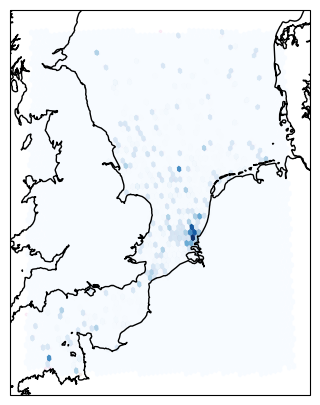

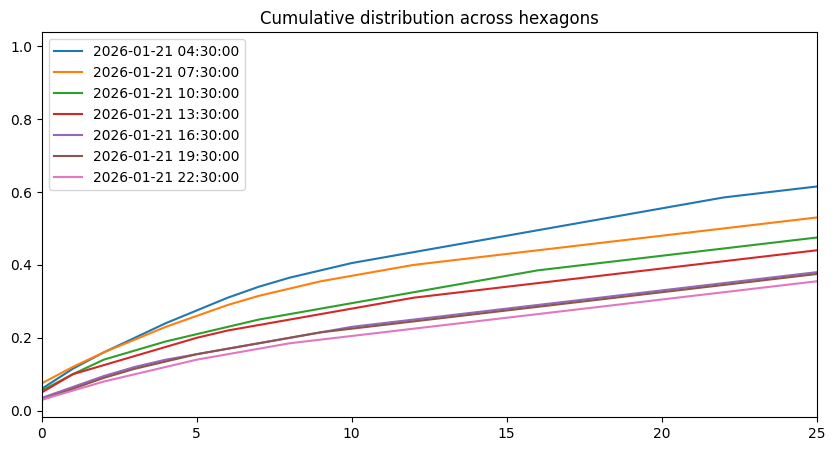

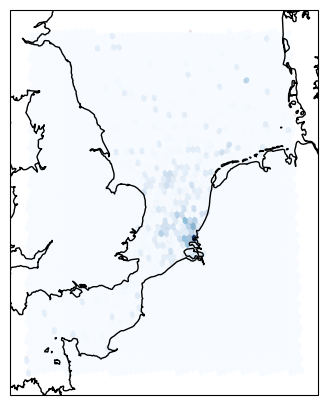

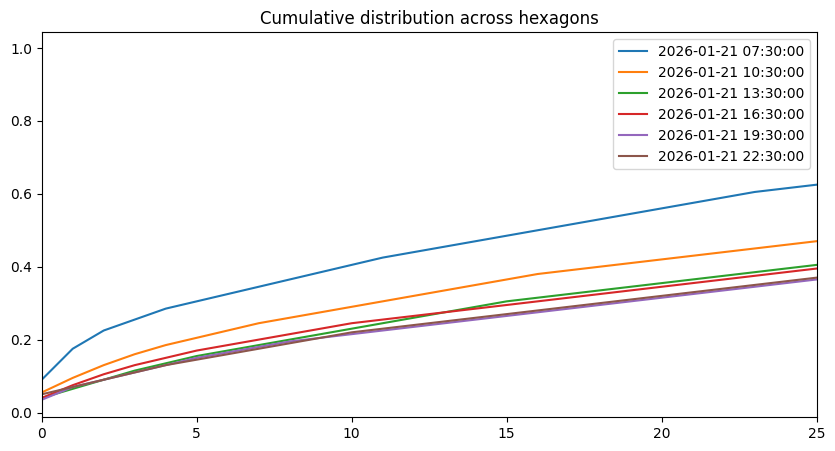

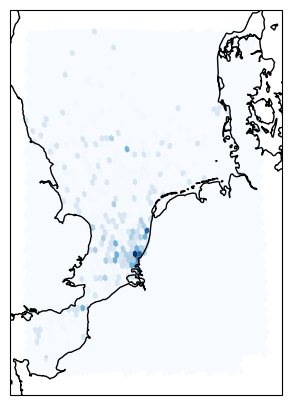

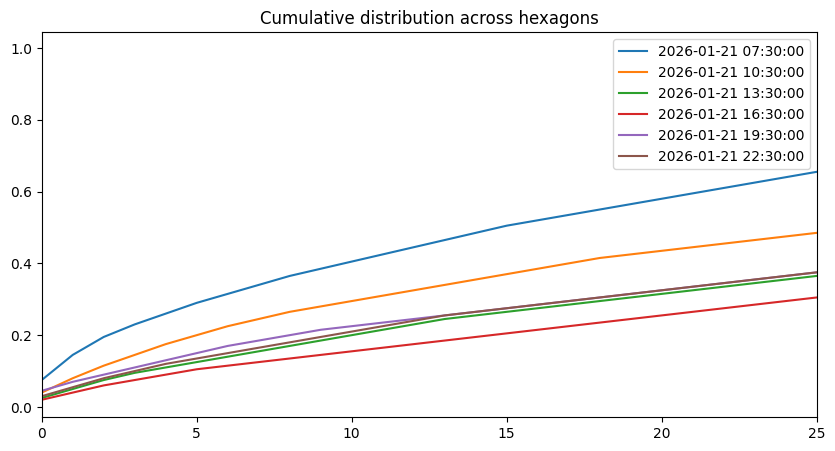

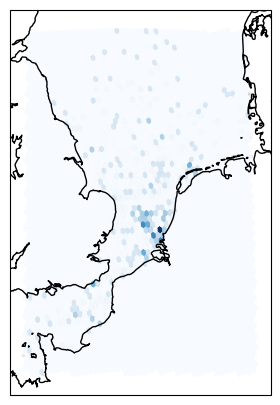

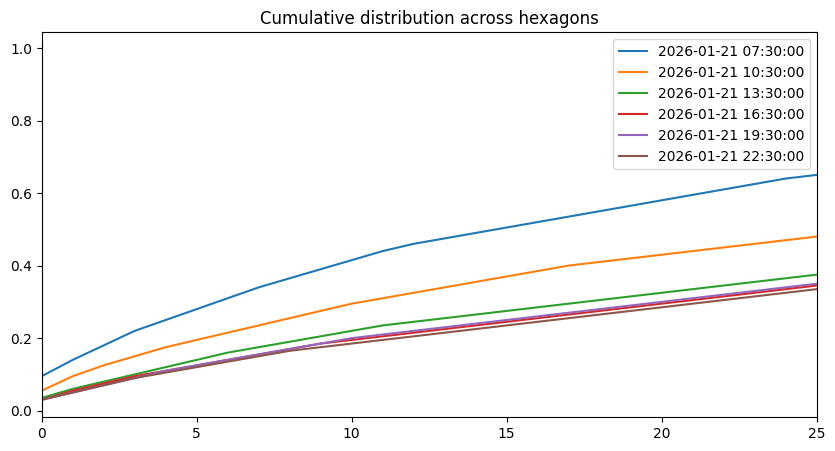

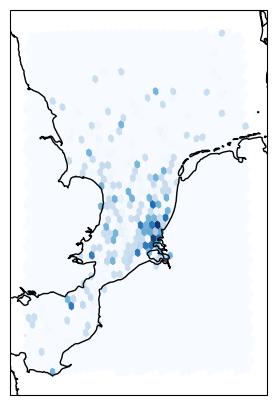

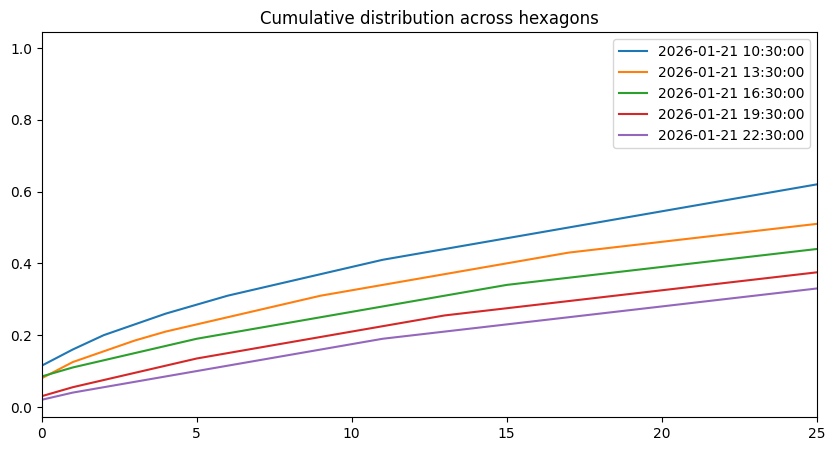

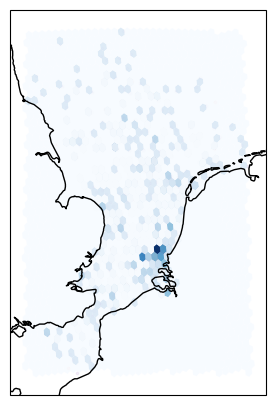

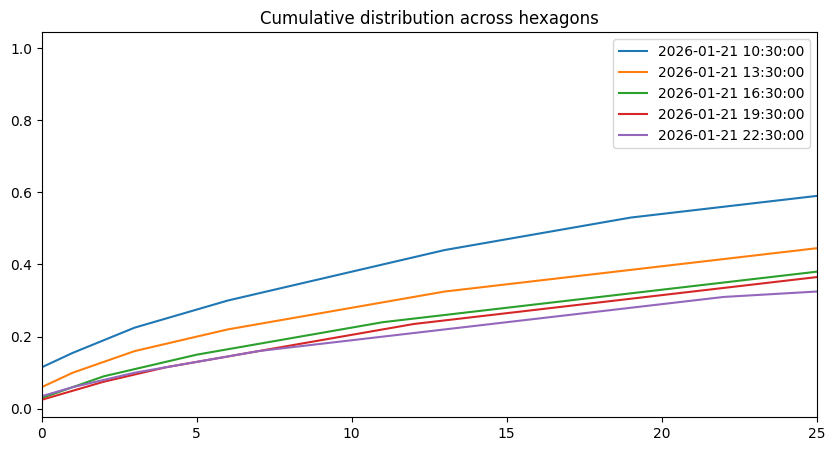

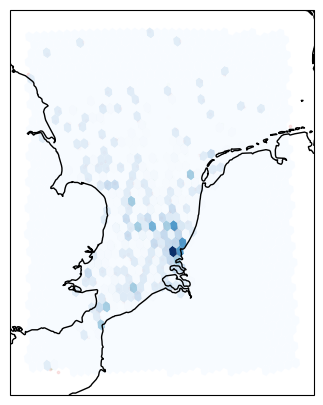

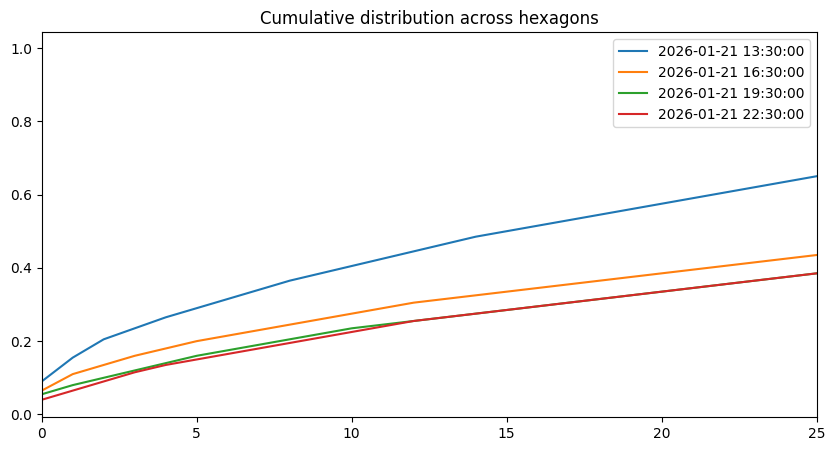

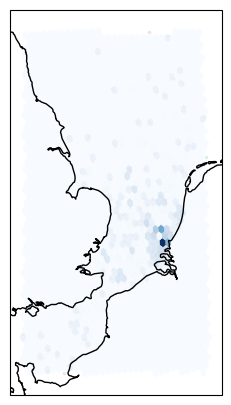

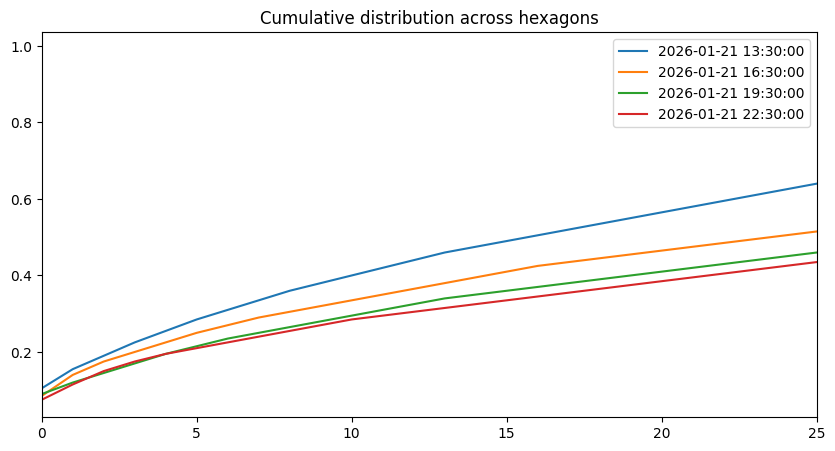

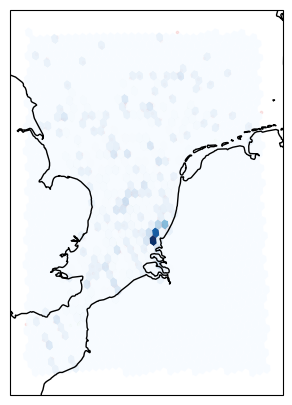

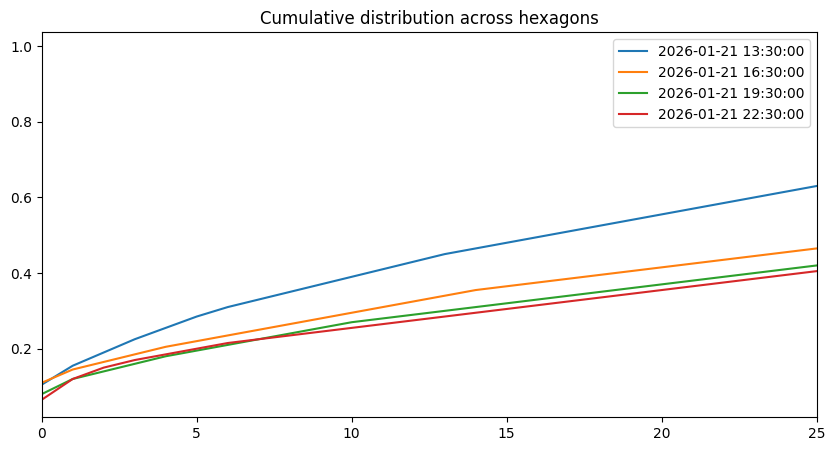

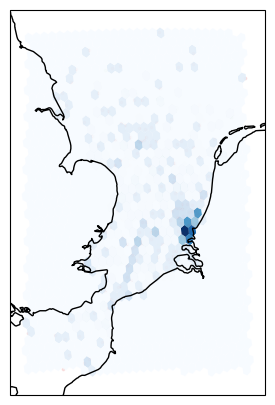

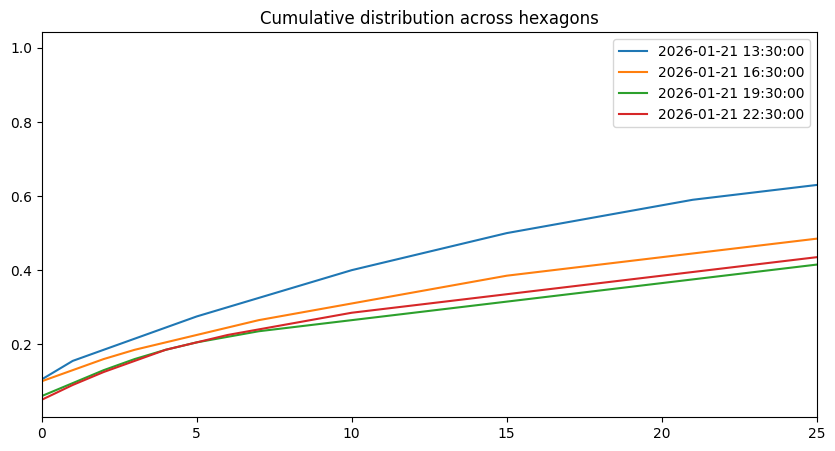

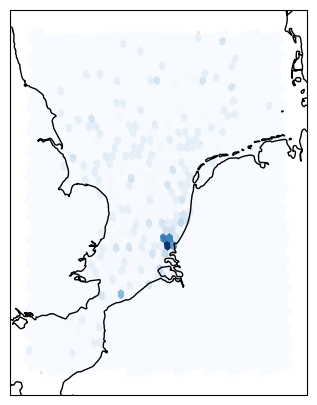

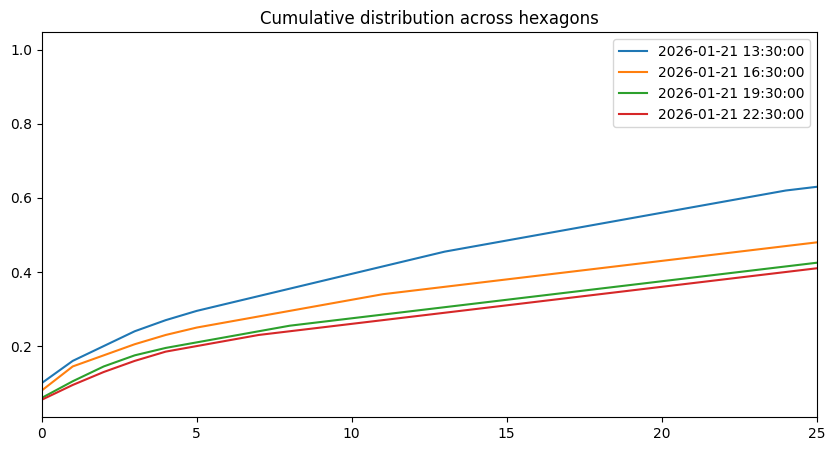

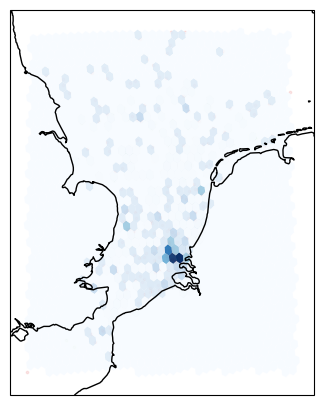

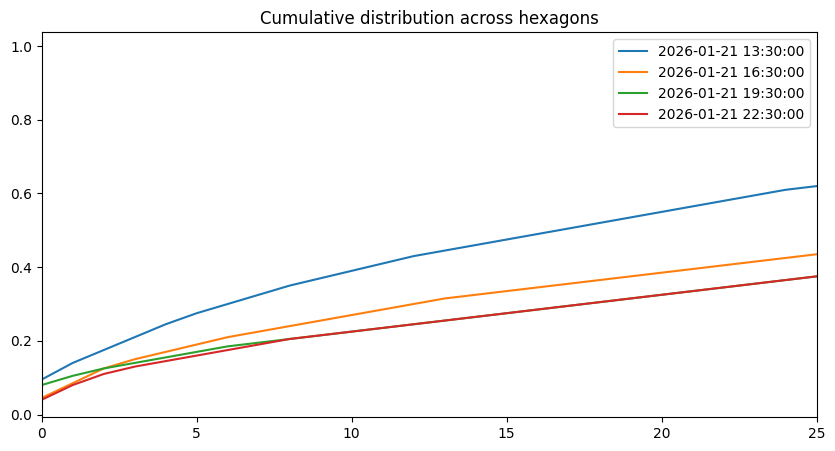

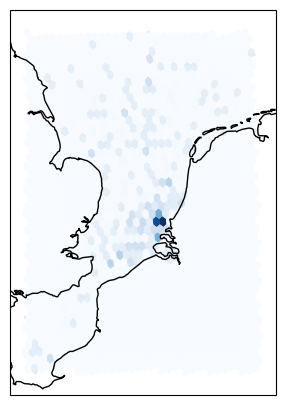

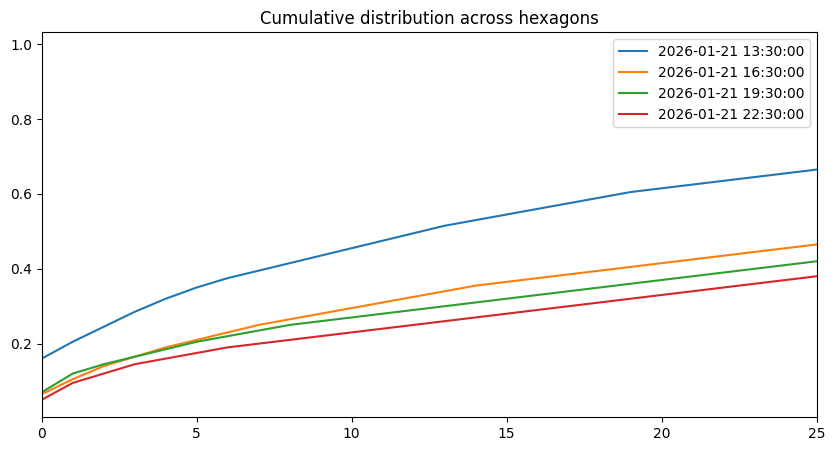

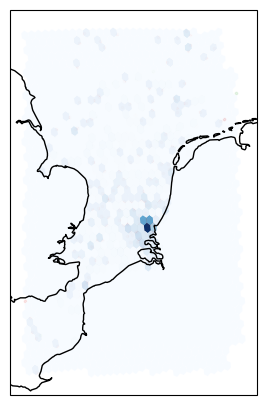

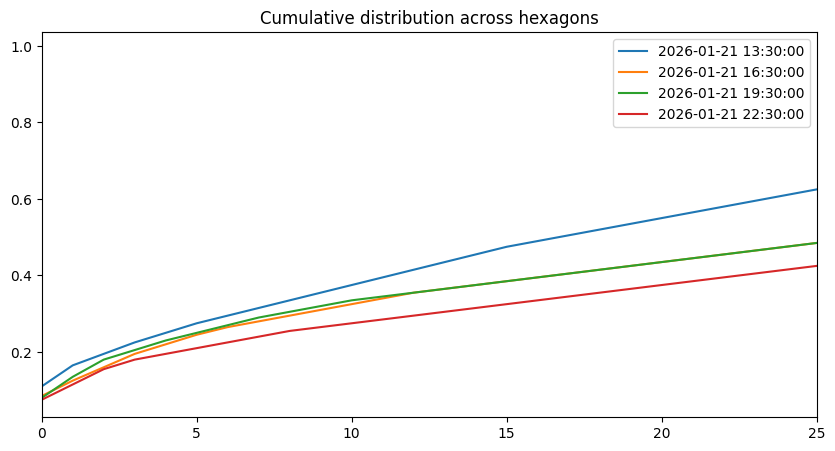

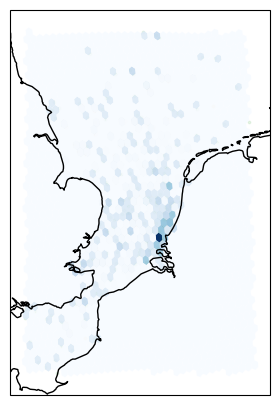

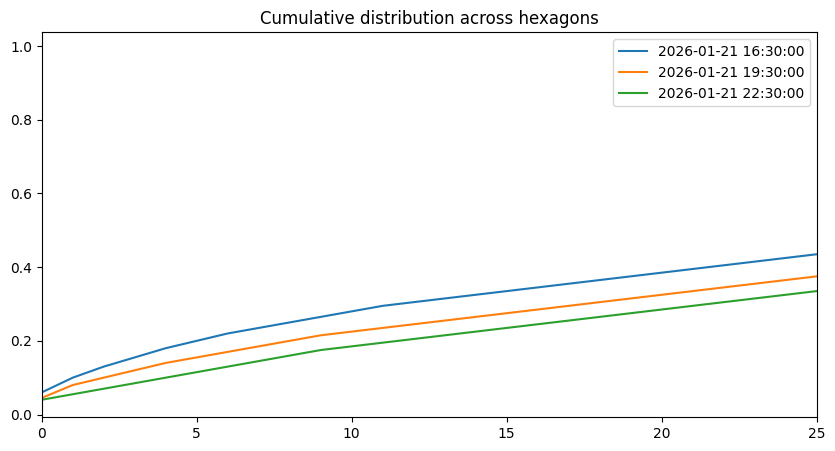

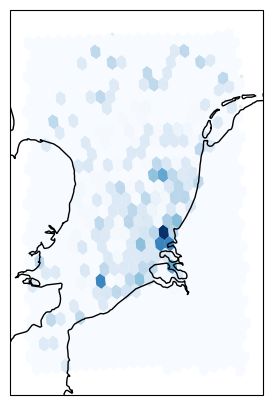

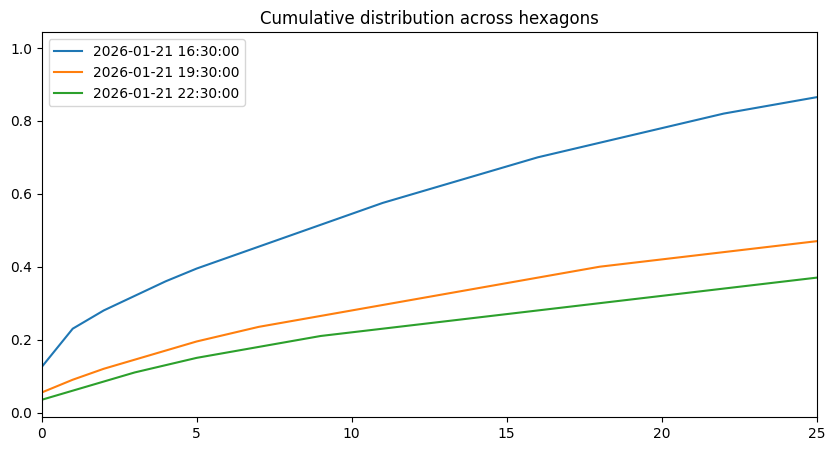

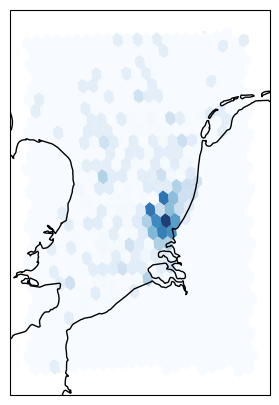

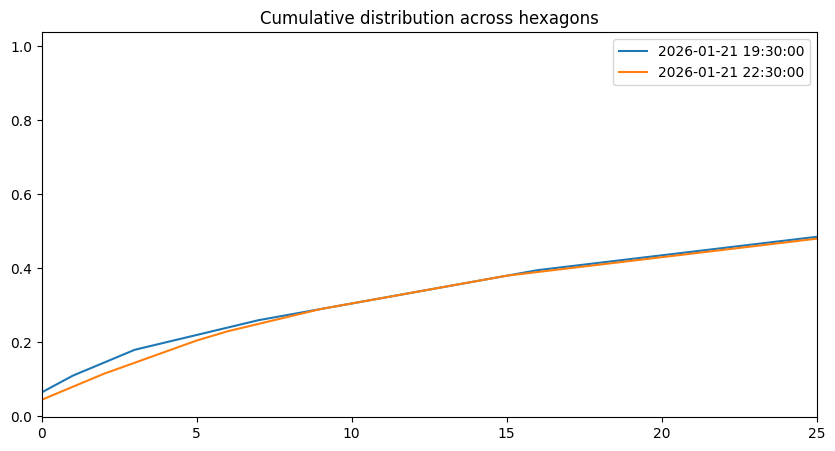

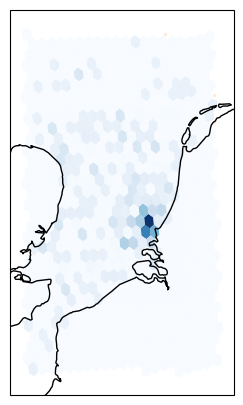

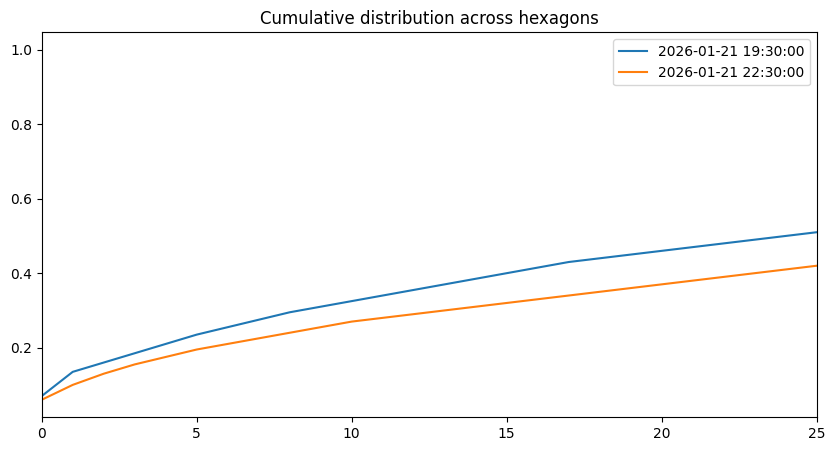

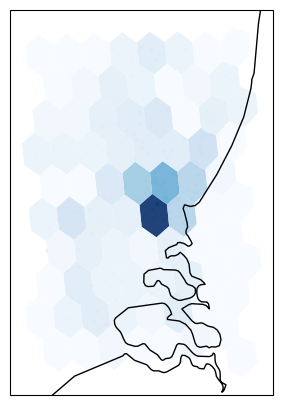

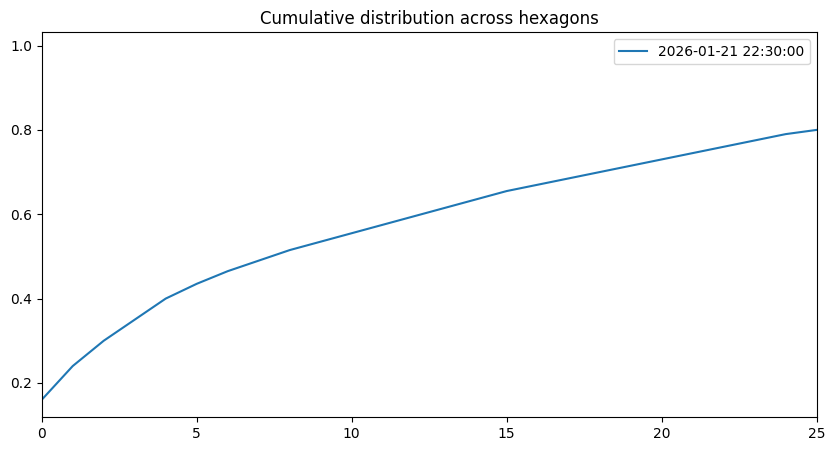

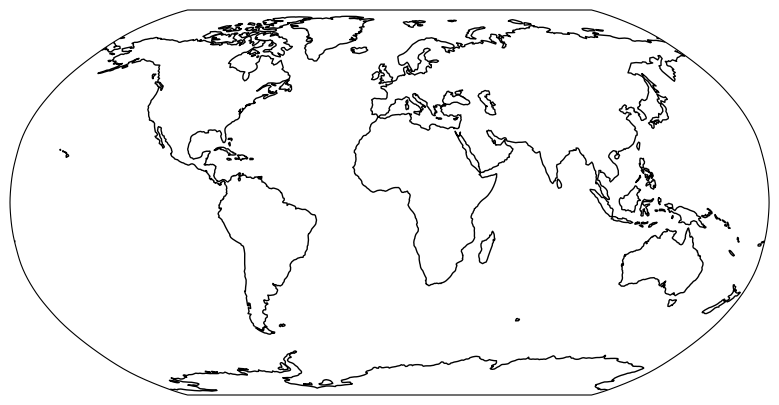

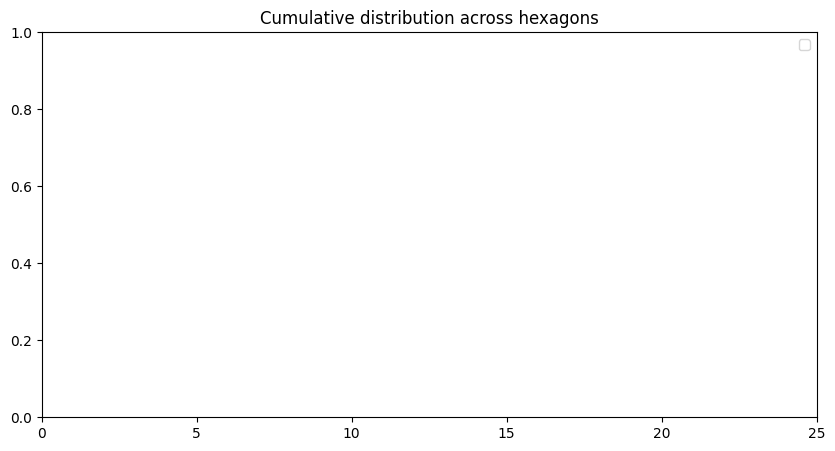

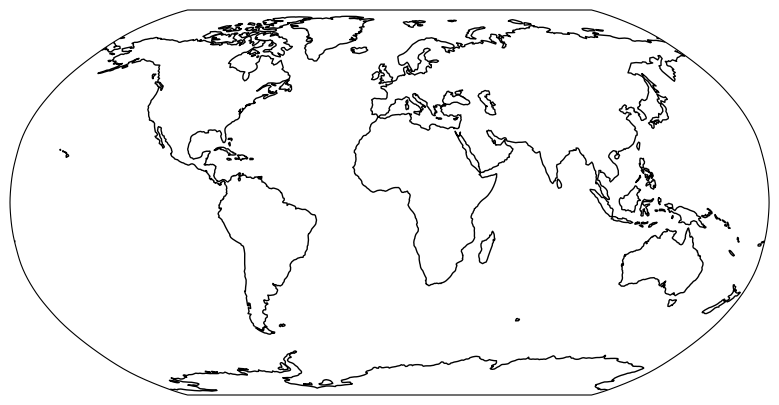

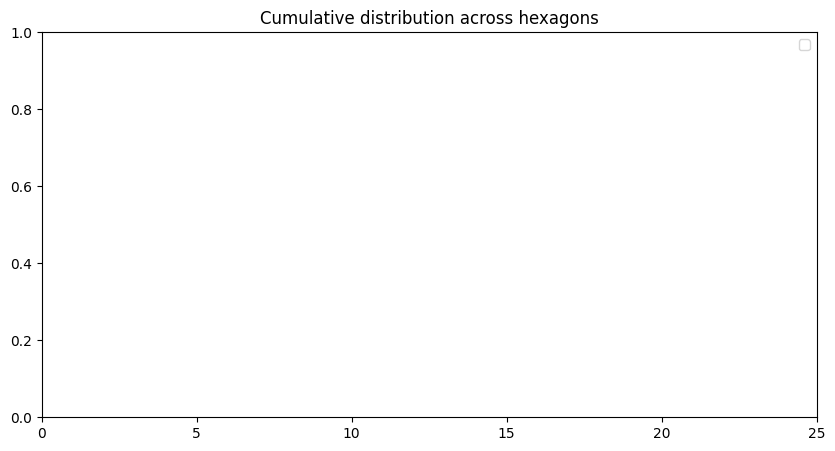

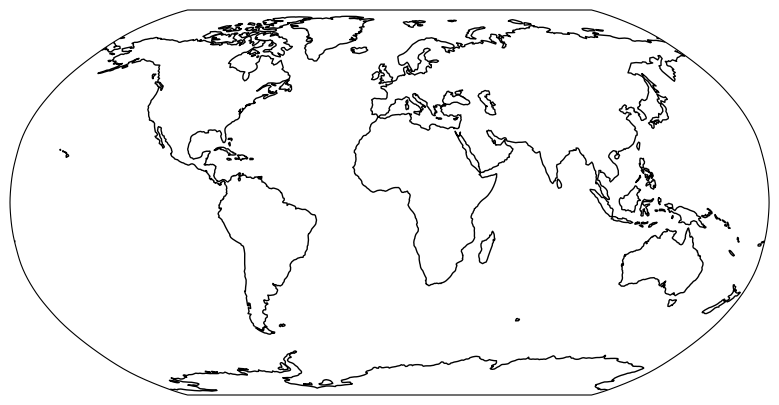

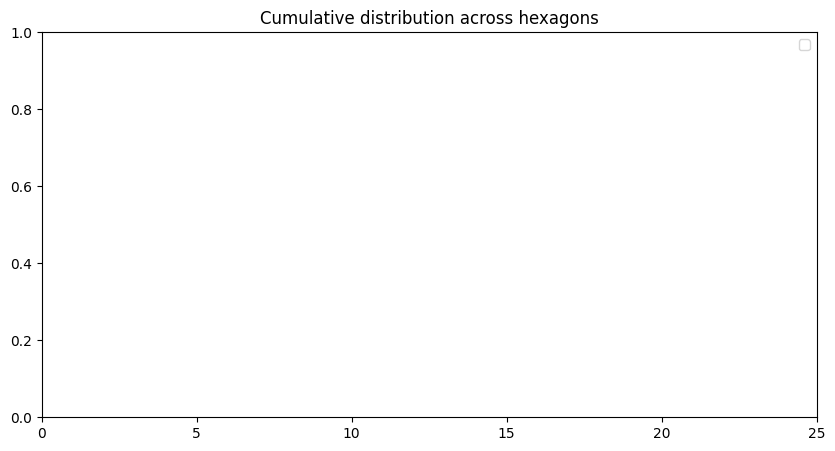

In [67]:
retcode = 1
while (retcode !=0):
    retcode = world_with_brokers.tick(print_forbidden_prefixes=["Downlink", "End of downlink", "Unlock uplink", "Unlock satellite after obs"])

In [68]:
broker._requests.columns

Index(['request', 'requested_pass', 'requested_constellation',
       'requested_satellite', 'constellation', 'satellite', 'assigned_pass',
       'assigned_downlink', 'status', 'data_product', 'scheduled_callback',
       'unscheduled_callback', 'ready_callback'],
      dtype='object')

In [69]:
retell_history(world_with_brokers)

Time: 2026-01-21 01:20:50.691974. Event: Event Obs, sat SKYSAT-C8 at 2026-01-21 01:20:50.691974
Observation: sat SKYSAT-C8 and opportunity Observation  at 2026-01-21 01:20:50.691974 by SKYSAT-C8 with InstrumentType.RGB. Look angle 73.67140590040195 | 70.91069913214582 az/dec deg, zenith angle 143.9198268649537 deg, range 498.2774171919814 km, duration 0:01:00
Time: 2026-01-21 01:20:50.691974. Event: Event ISL Downlink from sat SKYSAT-C8 at 2026-01-21 01:20:50.691974
Communication: station ISL to sat SKYSAT-C8 during pass ISL
Time: 2026-01-21 01:21:50.691974. Event: Event Unlock satellite after obs, sat SKYSAT-C8 at 2026-01-21 01:21:50.691974
Time: 2026-01-21 04:30:18.003079. Event: Event Obs, sat ICEYE-X6 at 2026-01-21 04:30:18.003079
Observation: sat ICEYE-X6 and opportunity Observation  at 2026-01-21 04:30:18.003079 by ICEYE-X6 with InstrumentType.SAR. Look angle 100.27959871684587 | 49.09723161238492 az/dec deg, zenith angle 118.62477503795593 deg, range 724.9064826124312 km, durati

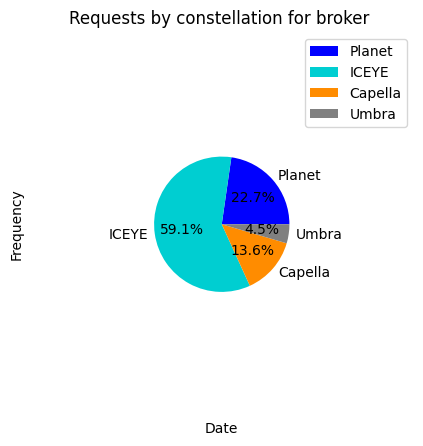

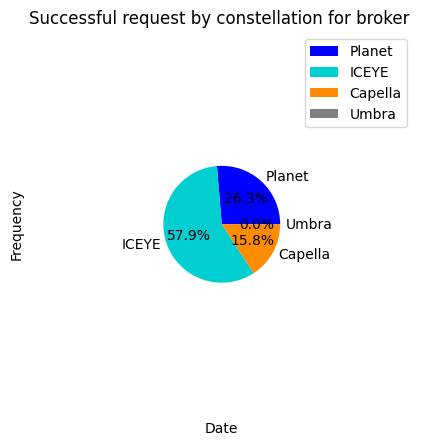

In [71]:
plot_request_statistics(broker._requests, constellation_colorer=constcolorer)

In [73]:
request_statistics(broker._requests)

19/22 (86.36363636363636%) of requests are in status ObservationStatus.DATA_RECEIVED
3/22 (13.636363636363635%) of requests are in status ObservationStatus.NO_OBSERVATION_OPPORTUNITIES
7/19 (36.84210526315789%) successful requests have a phenomenon detection

13/22 requests (59.09%) submitted to constellation ICEYE
11/19 successful requests (57.89%) submitted to constellation ICEYE
ICEYE submission success rate: 84.62%
1/22 requests (4.55%) submitted to constellation Umbra
0/19 successful requests (0.00%) submitted to constellation Umbra
Umbra submission success rate: 0.00%
3/22 requests (13.64%) submitted to constellation Capella
3/19 successful requests (15.79%) submitted to constellation Capella
Capella submission success rate: 100.00%
5/22 requests (22.73%) submitted to constellation Planet
5/19 successful requests (26.32%) submitted to constellation Planet
Planet submission success rate: 100.00%
 19/22 (86.36363636363636%) unique requests have at least one successful observation
7

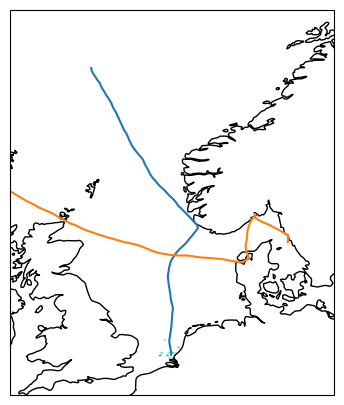

In [74]:
figglobal = plt.figure(figsize=(10,5))
ax = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
ax.coastlines()
_plot_offset_deg = 10

mapcenter = Location(lon_deg=3.8, lat_deg=60, alt_km=0)

axes_extents = (float(mapcenter.lon_deg)-_plot_offset_deg, float(mapcenter.lon_deg)+_plot_offset_deg, float(mapcenter.lat_deg)-_plot_offset_deg, float(mapcenter.lat_deg)+_plot_offset_deg)
ax.set_extent(axes_extents, crs=ccrs.PlateCarree())

for _chronicle in world_with_brokers.history:
    if type(_chronicle['event']) in [ObservationEvent]:
        _ax = plot_event(
            _chronicle,
            world_with_brokers,
            ax=ax,
            satellite_colors=satcolor,
            satellite_markers=satmarker,
            constellation_colors=constcolor,
            plot_time=False,
            plot_phenomena=False,
            plot_satellite_tracks=False,
            plot_ground_stations=False,
            plot_observation_gaze=False,
            plot_observation_target=False,
            plot_satellites=False
            )
        
ax.plot([pos.lon_deg for pos in phenomena_rotterdam],[pos.lat_deg for pos in phenomena_rotterdam],transform=ccrs.Geodetic(), label="TOI trajectory (Rotterdam)")
ax.plot([pos.lon_deg for pos in phenomena_gothenburg],[pos.lat_deg for pos in phenomena_gothenburg],transform=ccrs.Geodetic(), label="TOI trajectory (Gothenburg)")
plt.savefig("media/MSA2_observations_ship_sigmahdg_{}_sigmav_{}.png".format(heading_variance, speed_variance),bbox_inches='tight')
plt.savefig("media/MSA2_observations_ship_sigmahdg_{}_sigmav_{}.pdf".format(heading_variance, speed_variance),bbox_inches='tight')


In [75]:
print("There were {} observations".format(len([_e for _e in world_with_brokers.history if (type(_e['event']) in [ObservationEvent,])])))

There were 19 observations


In [76]:
PLOT_HISTORY_TL = False

_plot_offset_deg = 15
axes_extents = (float(Rotterdam.lon_deg)-_plot_offset_deg, float(Rotterdam.lon_deg)+_plot_offset_deg, float(Rotterdam.lat_deg)-_plot_offset_deg, float(Rotterdam.lat_deg)+_plot_offset_deg)

if PLOT_HISTORY_TL:

    plot_history(
        world_with_brokers,
        events_to_show=[ObservationEvent,],
        axes_extents=axes_extents,
        satellite_colors=satcolor,
        satellite_markers=satmarker,
        constellation_colors=constcolor,
        plot_observation_target=False,
        save_figure=True,
        save_prefix="media/MSA_2ships_history_",
        use_sequential_index=True,
        )